In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy import ndimage
import zipfile
import os
import glob
import warnings
warnings.filterwarnings("ignore")

print("imports done")

imports done


In [2]:
WORK_DIR = '/kaggle/working'
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'

# find all nc files across all subfolders
nc_files = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))

print(f"total .nc files found : {len(nc_files)}")
print(f"expected              : 46")
for f in nc_files:
    print(f"  {os.path.basename(f)}  {os.path.getsize(f)/1e6:.1f} MB")

total .nc files found : 46
expected              : 46
  era5_daily_1979.nc  11.1 MB
  era5_daily_1980.nc  11.1 MB
  era5_daily_1981.nc  11.1 MB
  era5_daily_1982.nc  11.1 MB
  era5_daily_1983.nc  11.1 MB
  era5_daily_1984.nc  11.1 MB
  era5_daily_1985.nc  11.1 MB
  era5_daily_1986.nc  11.1 MB
  era5_daily_1987.nc  11.1 MB
  era5_daily_1988.nc  11.1 MB
  era5_daily_1989.nc  11.1 MB
  era5_daily_1990.nc  11.1 MB
  era5_daily_1991.nc  11.1 MB
  era5_daily_1992.nc  11.1 MB
  era5_daily_1993.nc  11.1 MB
  era5_daily_1994.nc  11.1 MB
  era5_daily_1995.nc  11.1 MB
  era5_daily_1996.nc  11.1 MB
  era5_daily_1997.nc  11.1 MB
  era5_daily_1998.nc  11.1 MB
  era5_daily_1999.nc  11.1 MB
  era5_daily_2000.nc  11.1 MB
  era5_daily_2001.nc  11.1 MB
  era5_daily_2002.nc  11.1 MB
  era5_daily_2003.nc  11.1 MB
  era5_daily_2004.nc  11.1 MB
  era5_daily_2005.nc  11.1 MB
  era5_daily_2006.nc  11.1 MB
  era5_daily_2007.nc  11.1 MB
  era5_daily_2008.nc  11.1 MB
  era5_daily_2009.nc  11.1 MB
  era5_daily_201

In [7]:
# ── Cell 2 : load data ────────────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files  = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))

ds = xr.open_mfdataset(nc_files, combine='by_coords', engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat         = ds['latitude'].values.astype('float32')
lon         = ds['longitude'].values.astype('float32')
time        = ds['time'].values
times_pd    = pd.to_datetime(time)

print(f"shape : {data_precip.shape}")
print(f"lat   : {lat.min():.2f} → {lat.max():.2f}")
print(f"lon   : {lon.min():.2f} → {lon.max():.2f}")
print(f"time  : {str(times_pd[0])[:10]} → {str(times_pd[-1])[:10]}")

shape : (5612, 141, 161)
lat   : 5.00 → 40.00
lon   : 60.00 → 100.00
time  : 1979-06-01 → 2024-09-30


In [2]:
# ── Cell 2 : install regionmask ───────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask
print("regionmask ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.3 MB/s eta 0:00:00
regionmask ready


In [3]:
# ── Cell 4 : build India mask ─────────────────────────────────────────────────
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110

# find India index
print("India region:")
for i, name in enumerate(countries.names):
    if 'India' in name:
        print(f"  index {i} : {name}  abbrev: {countries.abbrevs[i]}")

India region:
  index 98 : India  abbrev: IND


In [8]:
# ── test : ocean mask effect on June anomaly ──────────────────────────────────

# land mask using natural earth land boundaries (not country-specific)
land_region = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_raw    = land_region.mask(lon, lat)

# True = land, False = ocean
land_mask = np.isnan(land_raw.values)   # (141, 161)

print(f"total cells  : {141*161}")
print(f"land cells   : {land_mask.sum()}")
print(f"ocean cells  : {(~land_mask).sum()}")
print(f"land fraction: {land_mask.mean()*100:.1f}%")

# apply ocean mask — ocean cells → NaN before threshold computation
data_masked_land = np.where(
    (data_precip > 1.0) & land_mask[np.newaxis, :, :],
    data_precip,
    np.nan
).astype('float32')

# compute threshold on land cells only
jjas_mask  = (times_pd.month >= 6) & (times_pd.month <= 9)
jjas_data  = data_masked_land[jjas_mask, :, :]

per_grid_99p5      = np.nanpercentile(jjas_data, 99.5, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99p5, 50.0).astype('float32')

# ocean cells → 999 so they never exceed
per_grid_threshold[~land_mask] = 999.0

print(f"\nthreshold over land cells only:")
print(f"  min  : {per_grid_threshold[land_mask].min():.1f} mm/day")
print(f"  max  : {per_grid_threshold[land_mask].max():.1f} mm/day")
print(f"  mean : {per_grid_threshold[land_mask].mean():.1f} mm/day")
print(f"  cells at floor (50 mm/day) : {(per_grid_threshold[land_mask] == 50.0).sum():,} / {land_mask.sum()}")

# exceedance mask
data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d     = np.broadcast_to(
    per_grid_threshold[np.newaxis, :, :], data_precip.shape
).copy().astype('float32')

c_test = (data_precip_safe > threshold_3d)

# monthly NT breakdown
print(f"\nmonthly NT with land-only mask:")
print(f"  {'month':<8} {'mean_NT':>10} {'exceedance_rate':>16}")
for month in [6, 7, 8, 9]:
    mask = (times_pd.month == month)
    nt   = c_test[mask].sum(axis=(1,2)).mean()
    rate = c_test[mask].mean() * 100
    print(f"  {month:<8} {nt:>10.1f} {rate:>15.3f}%")

total cells  : 22701
land cells   : 8803
ocean cells  : 13898
land fraction: 38.8%

threshold over land cells only:
  min  : 50.0 mm/day
  max  : 291.1 mm/day
  mean : 70.7 mm/day
  cells at floor (50 mm/day) : 3,634 / 8803

monthly NT with land-only mask:
  month       mean_NT  exceedance_rate
  6              36.0           0.159%
  7              12.9           0.057%
  8              15.5           0.068%
  9              18.0           0.079%


In [9]:
# ── test : India-only mask effect on June anomaly ─────────────────────────────
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_raw  = countries.mask(lon, lat)
india_mask = (india_raw.values == 98)   # True = India only

print(f"India cells  : {india_mask.sum()} / {141*161}")

# threshold on India cells only
data_masked_india = np.where(
    (data_precip > 1.0) & india_mask[np.newaxis, :, :],
    data_precip,
    np.nan
).astype('float32')

jjas_mask  = (times_pd.month >= 6) & (times_pd.month <= 9)
jjas_data  = data_masked_india[jjas_mask, :, :]

per_grid_99p5      = np.nanpercentile(jjas_data, 99.5, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99p5, 50.0).astype('float32')
per_grid_threshold[~india_mask] = 999.0

print(f"threshold over India cells:")
print(f"  min  : {per_grid_threshold[india_mask].min():.1f} mm/day")
print(f"  max  : {per_grid_threshold[india_mask].max():.1f} mm/day")
print(f"  mean : {per_grid_threshold[india_mask].mean():.1f} mm/day")
print(f"  cells at floor : {(per_grid_threshold[india_mask] == 50.0).sum():,} / {india_mask.sum()}")

# exceedance
data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d     = np.broadcast_to(
    per_grid_threshold[np.newaxis, :, :], data_precip.shape
).copy().astype('float32')

c_test = (data_precip_safe > threshold_3d)

print(f"\nmonthly NT with India-only mask:")
print(f"  {'month':<8} {'mean_NT':>10} {'exceedance_rate':>16}")
for month in [6, 7, 8, 9]:
    mask = (times_pd.month == month)
    nt   = c_test[mask].sum(axis=(1,2)).mean()
    rate = c_test[mask].mean() * 100
    print(f"  {month:<8} {nt:>10.1f} {rate:>15.3f}%")

India cells  : 4452 / 22701
threshold over India cells:
  min  : 50.0 mm/day
  max  : 283.0 mm/day
  mean : 87.6 mm/day
  cells at floor : 656 / 4452

monthly NT with India-only mask:
  month       mean_NT  exceedance_rate
  6              13.4           0.059%
  7              18.3           0.080%
  8              14.1           0.062%
  9               9.4           0.041%


In [10]:
# ── what does the India-only domain look like ─────────────────────────────────

lat_idx, lon_idx = np.where(india_mask)

print("India-only domain:")
print(f"  total grid cells     : {141*161} (full domain)")
print(f"  India cells          : {india_mask.sum()}")
print(f"  reduction            : {(1 - india_mask.sum()/(141*161))*100:.1f}% of cells removed")
print()
print(f"  lat range : {lat[lat_idx].min():.2f}N → {lat[lat_idx].max():.2f}N")
print(f"  lon range : {lon[lon_idx].min():.2f}E → {lon[lon_idx].max():.2f}E")
print()

# how many unique lat and lon values have at least one India cell
unique_lats = np.unique(lat[lat_idx])
unique_lons = np.unique(lon[lon_idx])
print(f"  unique lat values with India cells : {len(unique_lats)}")
print(f"  unique lon values with India cells : {len(unique_lons)}")
print(f"  bounding box grid size             : {len(unique_lats)} x {len(unique_lons)}")
print()

# distribution by latitude band
print("  India cells by latitude band:")
for lat_min, lat_max in [(5,10),(10,15),(15,20),(20,25),(25,30),(30,35),(35,40)]:
    band_mask = (lat[lat_idx] >= lat_min) & (lat[lat_idx] < lat_max)
    print(f"    {lat_min}N-{lat_max}N : {band_mask.sum()} cells")

India-only domain:
  total grid cells     : 22701 (full domain)
  India cells          : 4452
  reduction            : 80.4% of cells removed

  lat range : 8.25N → 35.25N
  lon range : 68.25E → 97.25E

  unique lat values with India cells : 109
  unique lon values with India cells : 117
  bounding box grid size             : 109 x 117

  India cells by latitude band:
    5N-10N : 52 cells
    10N-15N : 381 cells
    15N-20N : 755 cells
    20N-25N : 1499 cells
    25N-30N : 1370 cells
    30N-35N : 389 cells
    35N-40N : 6 cells


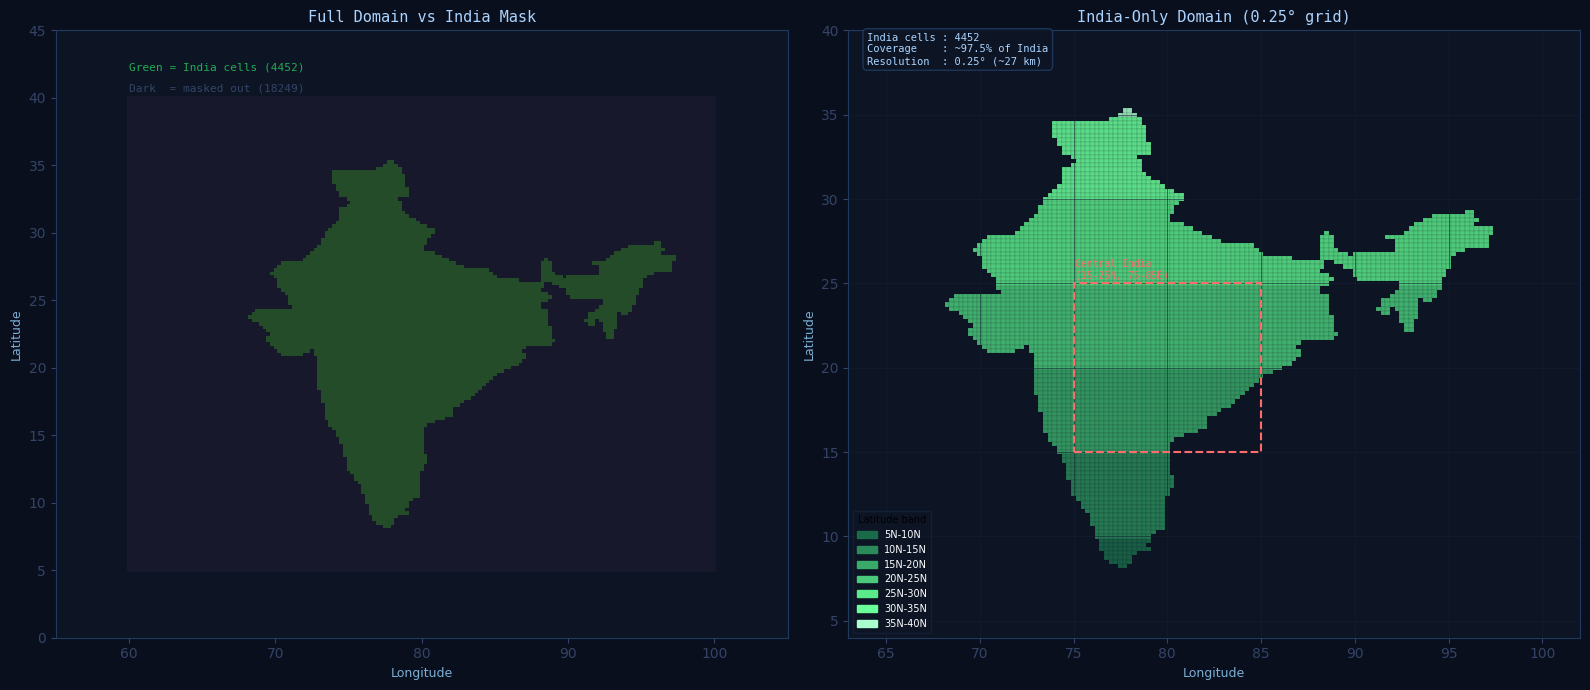

map saved ✓


In [11]:
# ── visualise India mask on map ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0a0f1e')

for ax in axes:
    ax.set_facecolor('#0d1525')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a5f')

# ── left panel : full domain showing what is masked ──
ax1 = axes[0]
ax1.set_title('Full Domain vs India Mask', 
              color='#aad4ff', fontsize=11, fontfamily='monospace')

# show all cells in grey
for li in range(len(lat)):
    for lj in range(len(lon)):
        color = '#2a5a2a' if india_mask[li, lj] else '#1a1a2e'
        rect  = mpatches.Rectangle(
            (lon[lj]-0.125, lat[li]-0.125), 0.25, 0.25,
            linewidth=0, facecolor=color, alpha=0.8
        )
        ax1.add_patch(rect)

ax1.set_xlim(55, 105)
ax1.set_ylim(0, 45)
ax1.set_xlabel('Longitude', color='#7aaed4', fontsize=9)
ax1.set_ylabel('Latitude',  color='#7aaed4', fontsize=9)
ax1.tick_params(colors='#334466')

# India box
ax1.text(60, 42, f'Green = India cells ({india_mask.sum()})',
         color='#2a5', fontsize=8, fontfamily='monospace')
ax1.text(60, 40.5, f'Dark  = masked out ({(~india_mask).sum()})',
         color='#334466', fontsize=8, fontfamily='monospace')

# ── right panel : India cells only zoomed in ──
ax2 = axes[1]
ax2.set_title('India-Only Domain (0.25° grid)', 
              color='#aad4ff', fontsize=11, fontfamily='monospace')

lat_idx, lon_idx = np.where(india_mask)

# colour by latitude band
band_colors = {
    (5,10) :'#1a6b4a', (10,15):'#2a8a5a',
    (15,20):'#3aaa6a', (20,25):'#4aca7a',
    (25,30):'#5aea8a', (30,35):'#6aff9a',
    (35,40):'#aaffcc'
}

for li, lj in zip(lat_idx, lon_idx):
    lat_val = lat[li]
    for (lo_b, hi_b), col in band_colors.items():
        if lo_b <= lat_val < hi_b:
            break
    rect = mpatches.Rectangle(
        (lon[lj]-0.125, lat[li]-0.125), 0.25, 0.25,
        linewidth=0.1, edgecolor='#0a0f1e',
        facecolor=col, alpha=0.85
    )
    ax2.add_patch(rect)

# Central India box — Nikumbh study region
from matplotlib.patches import Rectangle
ci_box = Rectangle((75, 15), 10, 10,
                    linewidth=1.5, edgecolor='#ff6b6b',
                    facecolor='none', linestyle='--', zorder=5)
ax2.add_patch(ci_box)
ax2.text(75.1, 25.3, 'Central India\n(15-25N, 75-85E)',
         color='#ff6b6b', fontsize=7, fontfamily='monospace')

ax2.set_xlim(63, 102)
ax2.set_ylim(4, 40)
ax2.set_xlabel('Longitude', color='#7aaed4', fontsize=9)
ax2.set_ylabel('Latitude',  color='#7aaed4', fontsize=9)
ax2.tick_params(colors='#334466')

# grid lines
for glon in range(65, 101, 5):
    ax2.axvline(glon, color='#141e33', linewidth=0.4)
for glat in range(5, 41, 5):
    ax2.axhline(glat, color='#141e33', linewidth=0.4)

# legend
legend_patches = [
    mpatches.Patch(color=col, label=f'{lo}N-{hi}N')
    for (lo, hi), col in band_colors.items()
]
ax2.legend(handles=legend_patches, loc='lower left',
           fontsize=7, framealpha=0.3,
           facecolor='#0d1525', edgecolor='#1e3a5f',
           labelcolor='white', title='Latitude band',
           title_fontsize=7)

# stats
ax2.text(64, 38,
         f'India cells : {india_mask.sum()}\n'
         f'Coverage    : ~97.5% of India\n'
         f'Resolution  : 0.25° (~27 km)',
         color='#aad4ff', fontsize=7.5,
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#0d1525',
                   edgecolor='#1e3a5f', alpha=0.9))

plt.tight_layout()
plt.savefig('/kaggle/working/india_mask_map.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0f1e')
plt.show()
print("map saved ✓")

In [17]:
# ── Cell 4 : India mask + Nikumbh threshold ───────────────────────────────────
import regionmask

RAINY_DAY_MIN = 1.0
PERCENTILE    = 99
FLOOR_MM      = 50.0

# build India mask
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_raw  = countries.mask(lon, lat)
india_mask = (india_raw.values == 98)   # (141, 161) — True = India

print(f"India cells  : {india_mask.sum()} / {141*161}")

# mask — India cells + rainy days only
data_masked = np.where(
    (data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
    data_precip,
    np.nan
).astype('float32')

# JJAS only
jjas_mask = (times_pd.month >= 6) & (times_pd.month <= 9)
jjas_data = data_masked[jjas_mask, :, :]

print(f"JJAS days    : {jjas_mask.sum()}")

# 99th percentile per grid cell
per_grid_99p5      = np.nanpercentile(jjas_data, PERCENTILE, axis=0).astype('float32')

# apply floor
per_grid_threshold = np.maximum(per_grid_99p5, FLOOR_MM).astype('float32')

# non-India cells → 999 so they never exceed
per_grid_threshold[~india_mask] = 999.0

# diagnostics
print(f"\nthreshold over India cells:")
print(f"  min  : {per_grid_threshold[india_mask].min():.1f} mm/day")
print(f"  max  : {per_grid_threshold[india_mask].max():.1f} mm/day")
print(f"  mean : {per_grid_threshold[india_mask].mean():.1f} mm/day")
print(f"  cells at floor (50 mm/day) : {(per_grid_threshold[india_mask] == 50.0).sum():,} / {india_mask.sum()}")
print(f"  cells above floor          : {(per_grid_threshold[india_mask] > 50.0).sum():,} / {india_mask.sum()}")
print("threshold done ✓")

India cells  : 4452 / 22701
JJAS days    : 5612

threshold over India cells:
  min  : 50.0 mm/day
  max  : 217.8 mm/day
  mean : 70.5 mm/day
  cells at floor (50 mm/day) : 1,166 / 4452
  cells above floor          : 3,286 / 4452
threshold done ✓


In [23]:
# correct exceedance rate — India cells only
india_days_total = india_mask.sum() * len(time)
india_exc_total  = c[:, india_mask].sum()

print(f"India cells          : {india_mask.sum()}")
print(f"total India cell-days: {india_days_total:,}")
print(f"exceeding cell-days  : {india_exc_total:,}")
print(f"exceedance rate over India only : {india_exc_total/india_days_total*100:.3f}%")

# also by month
print()
for month in [6,7,8,9]:
    mask = (times_pd.month == month)
    exc  = c[mask][:, india_mask].sum()
    tot  = india_mask.sum() * mask.sum()
    print(f"  month {month} : {exc/tot*100:.3f}%")

India cells          : 4452
total India cell-days: 24,984,624
exceeding cell-days  : 145,511
exceedance rate over India only : 0.582%

  month 6 : 0.531%
  month 7 : 0.787%
  month 8 : 0.627%
  month 9 : 0.377%


In [19]:
# ── Cell 6 : ERE detection ────────────────────────────────────────────────────
from scipy import ndimage

n_days    = len(time)
Loc_ERE   = np.full((n_days, len(lat), len(lon)), np.nan, dtype='float32')
Label_ERE = np.zeros((n_days, len(lat), len(lon)),         dtype='int32')

nt_per_day    = np.zeros(n_days, dtype='int32')
n_ere_per_day = np.zeros(n_days, dtype='int32')

struct4 = ndimage.generate_binary_structure(2, 1)   # 4-connectivity

for k in range(n_days):
    img = c[k].astype('int8')
    labeled, nr_objects = ndimage.label(img, structure=struct4)

    Label_ERE[k]     = labeled
    nt_per_day[k]    = int(img.sum())
    n_ere_per_day[k] = nr_objects

    if nr_objects > 0:
        counts       = np.bincount(labeled.ravel())[1:]
        nonzero_mask = labeled > 0
        Loc_ERE[k][nonzero_mask] = counts[labeled[nonzero_mask] - 1]

    if k % 1000 == 0:
        print(f"  day {k:>5}/{n_days}  |  EREs today: {nr_objects}")

print(f"\ndetection complete ✓")
print(f"mean NE per day : {n_ere_per_day.mean():.2f}")
print(f"max  NE one day : {n_ere_per_day.max()}")
print(f"mean NT per day : {nt_per_day.mean():.2f}")

  day     0/5612  |  EREs today: 0
  day  1000/5612  |  EREs today: 0
  day  2000/5612  |  EREs today: 2
  day  3000/5612  |  EREs today: 2
  day  4000/5612  |  EREs today: 5
  day  5000/5612  |  EREs today: 3

detection complete ✓
mean NE per day : 2.65
max  NE one day : 19
mean NT per day : 25.93


In [20]:
# how many days have zero EREs
zero_days = (n_ere_per_day == 0).sum()
jjas_days = len(time)
print(f"days with zero EREs : {zero_days} / {jjas_days} ({zero_days/jjas_days*100:.1f}%)")
print(f"days with >=1 ERE   : {(n_ere_per_day>0).sum()} / {jjas_days}")
print(f"days with >=5 EREs  : {(n_ere_per_day>=5).sum()} / {jjas_days}")

days with zero EREs : 1108 / 5612 (19.7%)
days with >=1 ERE   : 4504 / 5612
days with >=5 EREs  : 1099 / 5612


In [21]:
# what fraction of India cells have threshold = 50 mm/day (at floor)
# vs above floor — and what do their actual rainfall distributions look like

cells_at_floor   = (per_grid_threshold[india_mask] == 50.0).sum()
cells_above_floor = (per_grid_threshold[india_mask] > 50.0).sum()

print(f"India cells at floor (threshold=50)  : {cells_at_floor} ({cells_at_floor/india_mask.sum()*100:.1f}%)")
print(f"India cells above floor              : {cells_above_floor} ({cells_above_floor/india_mask.sum()*100:.1f}%)")

# for floor cells — how often do they exceed 50 mm/day
floor_cell_mask_2d = (per_grid_threshold == 50.0) & india_mask
jjas_precip = data_precip[jjas_mask]

floor_precip   = jjas_precip[:, floor_cell_mask_2d]   # (5612, n_floor_cells)
above_50       = (floor_precip > 50.0).mean() * 100
above_floor_precip = jjas_precip[:, (per_grid_threshold > 50.0) & india_mask]
above_thresh   = (above_floor_precip > per_grid_threshold[(per_grid_threshold > 50.0) & india_mask]).mean() * 100

print(f"\nfloor cells   — fraction of days exceeding 50 mm/day    : {above_50:.3f}%")
print(f"above-floor cells — fraction of days exceeding threshold : {above_thresh:.3f}%")

# what is the 99.5th percentile of floor cells before the floor
floor_99p5 = per_grid_99p5[floor_cell_mask_2d]
print(f"\n99.5th percentile of floor cells before floor:")
print(f"  min  : {floor_99p5.min():.1f} mm/day")
print(f"  max  : {floor_99p5.max():.1f} mm/day")
print(f"  mean : {floor_99p5.mean():.1f} mm/day")

India cells at floor (threshold=50)  : 1166 (26.2%)
India cells above floor              : 3286 (73.8%)

floor cells   — fraction of days exceeding 50 mm/day    : 0.247%
above-floor cells — fraction of days exceeding threshold : 0.701%

99.5th percentile of floor cells before floor:
  min  : 12.6 mm/day
  max  : 50.0 mm/day
  mean : 35.9 mm/day


In [25]:
# ── Cell 7 : validation ───────────────────────────────────────────────────────

# ── size distribution ──
all_sizes = Loc_ERE[~np.isnan(Loc_ERE)].astype(int)
print("ERE size distribution (cells at 0.25°):")
print(f"  total ERE-cells : {len(all_sizes):,}")
print()
for lo, hi, label in [(1,1,'small  =1 cell   '),
                       (2,5,'medium 2–5 cells '),
                       (6,9999,'large  ≥6 cells  ')]:
    n    = ((all_sizes >= lo) & (all_sizes <= hi)).sum()
    frac = n / len(all_sizes) * 100
    print(f"  {label} : {n:>10,}  ({frac:.1f}%)")

# ── seasonal cycle ──
print()
print("seasonal cycle:")
print(f"  {'month':<8} {'mean_NT':>10} {'mean_NE':>10}")
for month in [6, 7, 8, 9]:
    mask = (times_pd.month == month)
    print(f"  {month:<8} "
          f"{nt_per_day[mask].mean():>10.1f} "
          f"{n_ere_per_day[mask].mean():>10.2f}")

# ── June anomaly final check ──
june_nt = nt_per_day[times_pd.month==6].mean()
july_nt = nt_per_day[times_pd.month==7].mean()
print()
if july_nt > june_nt:
    print(f"✓ June anomaly resolved — July NT ({july_nt:.1f}) > June NT ({june_nt:.1f})")
else:
    print(f"⚠ June anomaly persists — June NT ({june_nt:.1f}) > July NT ({july_nt:.1f})")

# ── NE seasonal peak ──
print()
print("NE seasonal peak:")
ne_by_month = {m: n_ere_per_day[times_pd.month==m].mean() for m in [6,7,8,9]}
peak_month  = max(ne_by_month, key=ne_by_month.get)
for m, v in ne_by_month.items():
    flag = "← peak ✓" if m == peak_month and m in [7,8] else \
           "← peak ⚠ unexpected" if m == peak_month else ""
    print(f"  month {m} : {v:.2f}  {flag}")

# ── active vs weak years ──
print()
year_nt = {}
for yr in range(1979, 2025):
    mask = (times_pd.year == yr)
    year_nt[yr] = nt_per_day[mask].sum()

sorted_yrs = sorted(year_nt, key=year_nt.get, reverse=True)
print("top 5 active years (NT):")
for yr in sorted_yrs[:5]:
    print(f"  {yr} : {year_nt[yr]:,}")
print("top 5 weak years (NT):")
for yr in sorted_yrs[-5:]:
    print(f"  {yr} : {year_nt[yr]:,}")

# ── S-bar ──
print()
sbar = np.where(n_ere_per_day > 0,
                nt_per_day / n_ere_per_day,
                np.nan)
print(f"mean S-bar (NT/NE) : {np.nanmean(sbar):.2f} cells")
print(f"max  S-bar         : {np.nanmax(sbar):.2f} cells")
print(f"median S-bar       : {np.nanmedian(sbar):.2f} cells")

# ── zero ERE days ──
print()
zero_days = (n_ere_per_day == 0).sum()
print(f"days with zero EREs : {zero_days} / {len(time)} ({zero_days/len(time)*100:.1f}%)")
print(f"days with >=1 ERE   : {(n_ere_per_day>=1).sum()} / {len(time)}")
print(f"days with >=5 EREs  : {(n_ere_per_day>=5).sum()} / {len(time)}")

# ── known events quick check ──
print()
print("known event check:")
events = [
    {'name':'Uttarakhand 2013', 'dates':('2013-06-14','2013-06-18'),
     'lat':(30,32), 'lon':(77,81)},
    {'name':'Kerala 2018',      'dates':('2018-08-14','2018-08-20'),
     'lat':(8,12),  'lon':(74,78)},
]
for ev in events:
    d1  = pd.Timestamp(ev['dates'][0])
    d2  = pd.Timestamp(ev['dates'][1])
    t_mask = (times_pd >= d1) & (times_pd <= d2)
    lat_mask = (lat >= ev['lat'][0]) & (lat <= ev['lat'][1])
    lon_mask = (lon >= ev['lon'][0]) & (lon <= ev['lon'][1])
    window = Loc_ERE[t_mask][:, lat_mask, :][:, :, lon_mask]
    detected = (~np.isnan(window)).any()
    max_size = np.nanmax(window) if detected else 0
    print(f"  {ev['name']:<22} detected: {'YES ✓' if detected else 'NO ✗'}  "
          f"max_size: {int(max_size) if detected else 0} cells")

ERE size distribution (cells at 0.25°):
  total ERE-cells : 145,511

  small  =1 cell    :      3,888  (2.7%)
  medium 2–5 cells  :     15,994  (11.0%)
  large  ≥6 cells   :    125,629  (86.3%)

seasonal cycle:
  month       mean_NT    mean_NE
  6              23.6       2.32
  7              35.0       3.69
  8              27.9       2.95
  9              16.8       1.59

✓ June anomaly resolved — July NT (35.0) > June NT (23.6)

NE seasonal peak:
  month 6 : 2.32  
  month 7 : 3.69  ← peak ✓
  month 8 : 2.95  
  month 9 : 1.59  

top 5 active years (NT):
  2024 : 5,590
  2007 : 4,691
  1988 : 4,445
  1997 : 4,155
  1990 : 4,037
top 5 weak years (NT):
  1987 : 2,345
  2004 : 2,269
  1982 : 2,232
  1981 : 2,043
  1985 : 1,939

mean S-bar (NT/NE) : 10.66 cells
max  S-bar         : 176.00 cells
median S-bar       : 6.60 cells

days with zero EREs : 1108 / 5612 (19.7%)
days with >=1 ERE   : 4504 / 5612
days with >=5 EREs  : 1099 / 5612

known event check:
  Uttarakhand 2013       detecte

In [ ]:
# ── extended known event validation ──────────────────────────────────────────
events = [
    {'name':'Uttarakhand 2013',
     'dates':('2013-06-14','2013-06-18'),
     'lat':(29,33), 'lon':(76,82)},
    {'name':'Kerala 2018',
     'dates':('2018-08-14','2018-08-20'),
     'lat':(8,13),  'lon':(74,78)},
    {'name':'Mumbai 2005',
     'dates':('2005-07-26','2005-07-27'),
     'lat':(18,20), 'lon':(72,74)},
    {'name':'Assam 2012',
     'dates':('2012-06-20','2012-07-05'),
     'lat':(24,28), 'lon':(89,96)},
    {'name':'Chennai 2015',
     'dates':('2015-11-01','2015-12-05'),
     'lat':(11,14), 'lon':(79,81)},
    {'name':'Uttarakhand 2021',
     'dates':('2021-10-17','2021-10-19'),
     'lat':(29,32), 'lon':(78,81)},
    {'name':'Bihar floods 2007',
     'dates':('2007-08-01','2007-08-31'),
     'lat':(24,27), 'lon':(84,88)},
    {'name':'Leh cloudburst 2010',
     'dates':('2010-08-04','2010-08-06'),
     'lat':(33,35), 'lon':(76,78)},
]

print("="*65)
print("EXTENDED KNOWN EVENT VALIDATION")
print("="*65)

passed = 0
failed = 0

for ev in events:
    d1     = pd.Timestamp(ev['dates'][0])
    d2     = pd.Timestamp(ev['dates'][1])
    t_mask = (times_pd >= d1) & (times_pd <= d2)

    # check if dates are in dataset
    if t_mask.sum() == 0:
        print(f"\n  {ev['name']:<22} SKIP — dates outside dataset range")
        continue

    lat_mask = (lat >= ev['lat'][0]) & (lat <= ev['lat'][1])
    lon_mask = (lon >= ev['lon'][0]) & (lon <= ev['lon'][1])

    window   = Loc_ERE[t_mask][:, lat_mask, :][:, :, lon_mask]
    detected = (~np.isnan(window)).any()
    max_size = int(np.nanmax(window)) if detected else 0
    n_days   = int((~np.isnan(window)).any(axis=(1,2)).sum())

    if detected:
        passed += 1
        status = "YES ✓"
    else:
        failed += 1
        status = "NO  ✗"

    print(f"\n  {ev['name']:<22}"
          f"  detected: {status}"
          f"  max_size: {max_size:>5} cells"
          f"  active_days: {n_days}")

print()
print("="*65)
print(f"  PASSED : {passed}")
print(f"  FAILED : {failed}")
print(f"  TOTAL  : {passed+failed}")
print("="*65)

REAL WORLD EVENT DETECTION

In [27]:
# ── extended known event validation ──────────────────────────────────────────
events = [
    {'name':'Uttarakhand 2013',
     'dates':('2013-06-14','2013-06-18'),
     'lat':(29,33), 'lon':(76,82)},
    {'name':'Kerala 2018',
     'dates':('2018-08-14','2018-08-20'),
     'lat':(8,13),  'lon':(74,78)},
    {'name':'Mumbai 2005',
     'dates':('2005-07-26','2005-07-27'),
     'lat':(18,20), 'lon':(72,74)},
    {'name':'Assam 2012',
     'dates':('2012-06-20','2012-07-05'),
     'lat':(24,28), 'lon':(89,96)},
    {'name':'Chennai 2015',
     'dates':('2015-11-01','2015-12-05'),
     'lat':(11,14), 'lon':(79,81)},
    {'name':'Uttarakhand 2021',
     'dates':('2021-10-17','2021-10-19'),
     'lat':(29,32), 'lon':(78,81)},
    {'name':'Bihar floods 2007',
     'dates':('2007-08-01','2007-08-31'),
     'lat':(24,27), 'lon':(84,88)},
    {'name':'Leh cloudburst 2010',
     'dates':('2010-08-04','2010-08-06'),
     'lat':(33,35), 'lon':(76,78)},
]

print("="*65)
print("EXTENDED KNOWN EVENT VALIDATION")
print("="*65)

passed = 0
failed = 0

for ev in events:
    d1     = pd.Timestamp(ev['dates'][0])
    d2     = pd.Timestamp(ev['dates'][1])
    t_mask = (times_pd >= d1) & (times_pd <= d2)

    # check if dates are in dataset
    if t_mask.sum() == 0:
        print(f"\n  {ev['name']:<22} SKIP — dates outside dataset range")
        continue

    lat_mask = (lat >= ev['lat'][0]) & (lat <= ev['lat'][1])
    lon_mask = (lon >= ev['lon'][0]) & (lon <= ev['lon'][1])

    window   = Loc_ERE[t_mask][:, lat_mask, :][:, :, lon_mask]
    detected = (~np.isnan(window)).any()
    max_size = int(np.nanmax(window)) if detected else 0
    n_days   = int((~np.isnan(window)).any(axis=(1,2)).sum())

    if detected:
        passed += 1
        status = "YES ✓"
    else:
        failed += 1
        status = "NO  ✗"

    print(f"\n  {ev['name']:<22}"
          f"  detected: {status}"
          f"  max_size: {max_size:>5} cells"
          f"  active_days: {n_days}")

print()
print("="*65)
print(f"  PASSED : {passed}")
print(f"  FAILED : {failed}")
print(f"  TOTAL  : {passed+failed}")
print("="*65)

EXTENDED KNOWN EVENT VALIDATION

  Uttarakhand 2013        detected: YES ✓  max_size:   117 cells  active_days: 3

  Kerala 2018             detected: YES ✓  max_size:    67 cells  active_days: 3

  Mumbai 2005             detected: YES ✓  max_size:     8 cells  active_days: 2

  Assam 2012              detected: YES ✓  max_size:    71 cells  active_days: 6

  Chennai 2015           SKIP — dates outside dataset range

  Uttarakhand 2021       SKIP — dates outside dataset range

  Bihar floods 2007       detected: YES ✓  max_size:    19 cells  active_days: 7

  Leh cloudburst 2010     detected: NO  ✗  max_size:     0 cells  active_days: 0

  PASSED : 5
  FAILED : 1
  TOTAL  : 6


In [28]:
# ── ERE size classification — Nikumbh physical area equivalent at 0.25° ───────
# Nikumbh categories based on physical area:
# Small  : <  12,300 km²  →  1–15  cells at 0.25° (~770 km²/cell)
# Medium : 12,300–70,000 km²  →  16–90  cells
# Large  : ≥  70,000 km²  →  ≥91   cells

CELL_AREA_KM2 = 770   # approximate cell area at 0.25° (~20°N)

SMALL_MIN  = 1
SMALL_MAX  = 15
MEDIUM_MIN = 16
MEDIUM_MAX = 90
LARGE_MIN  = 91

print(f"Size categories (Nikumbh physical area equivalent at 0.25°):")
print(f"  small  :  1–15  cells  ({SMALL_MIN*CELL_AREA_KM2:,}–{SMALL_MAX*CELL_AREA_KM2:,} km²)")
print(f"  medium : 16–90  cells  ({MEDIUM_MIN*CELL_AREA_KM2:,}–{MEDIUM_MAX*CELL_AREA_KM2:,} km²)")
print(f"  large  : ≥91    cells  (≥{LARGE_MIN*CELL_AREA_KM2:,} km²)")
print(f"  Nikumbh large threshold : ≥70,000 km²")
print()

small_count  = 0
medium_count = 0
large_count  = 0

# also track per year for trend glimpse
year_counts = {yr: {'small':0, 'medium':0, 'large':0}
               for yr in range(1979, 2025)}

for k in range(len(time)):
    if n_ere_per_day[k] == 0:
        continue

    yr      = times_pd[k].year
    labeled = Label_ERE[k]
    counts  = np.bincount(labeled.ravel())[1:]

    s = (counts <= SMALL_MAX).sum()
    m = ((counts >= MEDIUM_MIN) & (counts <= MEDIUM_MAX)).sum()
    l = (counts >= LARGE_MIN).sum()

    small_count  += s
    medium_count += m
    large_count  += l

    year_counts[yr]['small']  += s
    year_counts[yr]['medium'] += m
    year_counts[yr]['large']  += l

total_ere = small_count + medium_count + large_count

print("ERE object classification:")
print(f"  total ERE objects : {total_ere:,}")
print()
print(f"  small  ( 1–15  cells, <11,550 km²)  : "
      f"{small_count:>8,}  ({small_count/total_ere*100:.1f}%)")
print(f"  medium (16–90  cells, 12,320–69,300 km²) : "
      f"{medium_count:>8,}  ({medium_count/total_ere*100:.1f}%)")
print(f"  large  (≥91    cells, ≥70,070 km²)  : "
      f"{large_count:>8,}  ({large_count/total_ere*100:.1f}%)")
print()
print(f"  mean small  per day : {small_count/len(time):.3f}")
print(f"  mean medium per day : {medium_count/len(time):.3f}")
print(f"  mean large  per day : {large_count/len(time):.3f}")

# ── per year large ERE counts ──
print()
print("large EREs per year:")
print(f"  {'year':<6} {'small':>8} {'medium':>8} {'large':>8} {'total':>8}")
for yr in range(1979, 2025):
    s = year_counts[yr]['small']
    m = year_counts[yr]['medium']
    l = year_counts[yr]['large']
    t = s + m + l
    print(f"  {yr:<6} {s:>8} {m:>8} {l:>8} {t:>8}")

# ── quick trend check on large EREs ──
print()
import numpy as np
years      = np.array(list(range(1979, 2025)))
large_yr   = np.array([year_counts[yr]['large'] for yr in years])
medium_yr  = np.array([year_counts[yr]['medium'] for yr in years])
small_yr   = np.array([year_counts[yr]['small'] for yr in years])

# linear fit
for name, arr in [('small', small_yr),
                  ('medium', medium_yr),
                  ('large', large_yr)]:
    slope = np.polyfit(years, arr, 1)[0]
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"  {name:<8} trend : {slope:+.3f} EREs/year  ({direction})")

Size categories (Nikumbh physical area equivalent at 0.25°):
  small  :  1–15  cells  (770–11,550 km²)
  medium : 16–90  cells  (12,320–69,300 km²)
  large  : ≥91    cells  (≥70,070 km²)
  Nikumbh large threshold : ≥70,000 km²

ERE object classification:
  total ERE objects : 14,864

  small  ( 1–15  cells, <11,550 km²)  :   12,380  (83.3%)
  medium (16–90  cells, 12,320–69,300 km²) :    2,345  (15.8%)
  large  (≥91    cells, ≥70,070 km²)  :      139  (0.9%)

  mean small  per day : 2.206
  mean medium per day : 0.418
  mean large  per day : 0.025

large EREs per year:
  year      small   medium    large    total
  1979        228       42        2      272
  1980        227       39        2      268
  1981        166       30        1      197
  1982        183       44        0      227
  1983        286       53        3      342
  1984        270       62        1      333
  1985        254       29        0      283
  1986        237       59        3      299
  1987        222  

In [31]:
# ── NT, NE, S-bar annual trend analysis — Nikumbh replication ────────────────
from scipy import stats

# ── compute annual time series ──
years      = np.arange(1979, 2025)
NT_annual  = np.zeros(len(years), dtype='float32')
NE_annual  = np.zeros(len(years), dtype='float32')

for i, yr in enumerate(years):
    yr_mask        = (times_pd.year == yr)
    NT_annual[i]   = nt_per_day[yr_mask].sum()
    NE_annual[i]   = n_ere_per_day[yr_mask].sum()

Sbar_annual = np.where(NE_annual > 0, NT_annual / NE_annual, np.nan)

print("Annual NT, NE, S-bar (1979–2024):")
print(f"  {'year':<6} {'NT':>8} {'NE':>8} {'S-bar':>8}")
for i, yr in enumerate(years):
    print(f"  {yr:<6} {NT_annual[i]:>8.0f} {NE_annual[i]:>8.0f} {Sbar_annual[i]:>8.3f}")

# ── Mann-Kendall trend test ──
# using scipy linregress as proxy — proper MK needs pymannkendall
print()
print("="*50)
print("TREND ANALYSIS")
print("="*50)

for name, arr in [('NT',   NT_annual),
                  ('NE',   NE_annual),
                  ('Sbar', Sbar_annual)]:
    # linear regression
    slope, intercept, r, p, se = stats.linregress(years, arr)
    print(f"\n  {name}:")
    print(f"    slope     : {slope:+.4f} per year")
    print(f"    p-value   : {p:.4f}")
    print(f"    r²        : {r**2:.4f}")
    sig = "SIGNIFICANT ✓" if p < 0.05 else "not significant ✗"
    print(f"    trend     : {sig}")
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"    direction : {direction}")

Annual NT, NE, S-bar (1979–2024):
  year         NT       NE    S-bar
  1979       2577      272    9.474
  1980       2626      268    9.799
  1981       2043      197   10.371
  1982       2232      227    9.833
  1983       3387      342    9.904
  1984       3198      333    9.604
  1985       1939      283    6.852
  1986       3390      299   11.338
  1987       2345      261    8.985
  1988       4445      413   10.763
  1989       3866      333   11.610
  1990       4037      385   10.486
  1991       3751      346   10.841
  1992       2663      271    9.827
  1993       3352      318   10.541
  1994       3873      343   11.292
  1995       3433      364    9.431
  1996       3748      318   11.786
  1997       4155      342   12.149
  1998       2744      338    8.118
  1999       2767      330    8.385
  2000       3179      283   11.233
  2001       2593      297    8.731
  2002       2689      304    8.845
  2003       2456      323    7.604
  2004       2269      268    

In [32]:
# ── sensitivity test — remove 2024 ───────────────────────────────────────────
from scipy import stats

years_no2024    = years[years != 2024]
NT_no2024       = NT_annual[years != 2024]
NE_no2024       = NE_annual[years != 2024]
Sbar_no2024     = Sbar_annual[years != 2024]

print("TREND ANALYSIS WITHOUT 2024:")
print()
for name, arr in [('NT',   NT_no2024),
                  ('NE',   NE_no2024),
                  ('Sbar', Sbar_no2024)]:
    slope, _, r, p, _ = stats.linregress(years_no2024, arr)
    sig = "SIGNIFICANT ✓" if p < 0.05 else "not significant ✗"
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"  {name}:")
    print(f"    slope : {slope:+.4f}/year")
    print(f"    p     : {p:.4f}  {sig}")
    print(f"    dir   : {direction}")
    print()

TREND ANALYSIS WITHOUT 2024:

  NT:
    slope : +2.2544/year
    p     : 0.7536  not significant ✗
    dir   : increasing

  NE:
    slope : +1.0644/year
    p     : 0.0252  SIGNIFICANT ✓
    dir   : increasing

  Sbar:
    slope : -0.0231/year
    p     : 0.1135  not significant ✗
    dir   : decreasing



NE increase is driven by small EREs only

In [33]:
# ── is NE increase driven by small EREs? ─────────────────────────────────────
# compute annual NE broken down by size category

NE_small_annual  = np.zeros(len(years))
NE_medium_annual = np.zeros(len(years))
NE_large_annual  = np.zeros(len(years))

for i, yr in enumerate(years):
    yr_mask = (times_pd.year == yr)
    yr_indices = np.where(yr_mask)[0]
    
    for k in yr_indices:
        if n_ere_per_day[k] == 0:
            continue
        labeled = Label_ERE[k]
        labels  = np.unique(labeled)
        labels  = labels[labels > 0]
        
        for lbl in labels:
            cell_idx = np.argwhere(labeled == lbl)
            lat_idxs = cell_idx[:, 0]
            ere_area = cell_area_2d[lat_idxs, 0].sum()
            
            if ere_area < 12300:
                NE_small_annual[i]  += 1
            elif ere_area < 70000:
                NE_medium_annual[i] += 1
            else:
                NE_large_annual[i]  += 1

print("Annual NE by size category — trend:")
print()
for name, arr in [('NE_small',  NE_small_annual),
                  ('NE_medium', NE_medium_annual),
                  ('NE_large',  NE_large_annual)]:
    slope, _, r, p, _ = stats.linregress(years, arr)
    sig = "SIGNIFICANT ✓" if p < 0.05 else "not significant ✗"
    print(f"  {name:<12} slope: {slope:+.4f}/yr  "
          f"p={p:.4f}  {sig}")

Annual NE by size category — trend:

  NE_small     slope: +1.4279/yr  p=0.0019  SIGNIFICANT ✓
  NE_medium    slope: +0.0604/yr  p=0.5909  not significant ✗
  NE_large     slope: +0.0155/yr  p=0.5499  not significant ✗


In [34]:
# S-bar excluding small EREs
Sbar_medium_large = np.where(
    (NE_medium_annual + NE_large_annual) > 0,
    NT_annual / (NE_medium_annual + NE_large_annual),
    np.nan
)

slope, _, r, p, _ = stats.linregress(years, Sbar_medium_large)
print(f"S-bar (medium+large only):")
print(f"  slope : {slope:+.4f}/year")
print(f"  p     : {p:.4f}")
print(f"  dir   : {'increasing' if slope > 0 else 'decreasing'}")

S-bar (medium+large only):
  slope : +0.0215/year
  p     : 0.8000
  dir   : increasing


In [35]:
# ── Central India trend analysis — exact Nikumbh domain ──────────────────────
# Central India: 15–25N, 75–85E

CI_lat_min, CI_lat_max = 15, 25
CI_lon_min, CI_lon_max = 75, 85

# Central India cell mask
ci_mask = (
    (lat[:, np.newaxis] >= CI_lat_min) &
    (lat[:, np.newaxis] <= CI_lat_max) &
    (lon[np.newaxis, :] >= CI_lon_min) &
    (lon[np.newaxis, :] <= CI_lon_max)
)  # (141, 161)

print(f"Central India cells : {ci_mask.sum()}")

# an ERE belongs to Central India if AT LEAST ONE cell is in the CI box
# exactly as Nikumbh defined it
NT_ci     = np.zeros(len(years))
NE_ci     = np.zeros(len(years))

for i, yr in enumerate(years):
    yr_mask    = (times_pd.year == yr)
    yr_indices = np.where(yr_mask)[0]

    for k in yr_indices:
        if n_ere_per_day[k] == 0:
            continue
        labeled = Label_ERE[k]
        labels  = np.unique(labeled)
        labels  = labels[labels > 0]

        for lbl in labels:
            cell_idx  = np.argwhere(labeled == lbl)
            lat_idxs  = cell_idx[:, 0]
            lon_idxs  = cell_idx[:, 1]

            # check if any cell of this ERE is in Central India
            in_ci = ci_mask[lat_idxs, lon_idxs].any()

            if in_ci:
                # NT contribution — only cells within CI box
                ci_cells = ci_mask[lat_idxs, lon_idxs].sum()
                NT_ci[i] += ci_cells
                NE_ci[i] += 1

Sbar_ci = np.where(NE_ci > 0, NT_ci / NE_ci, np.nan)

print()
print("Central India NT, NE, S-bar trend:")
print()
for name, arr in [('NT',   NT_ci),
                  ('NE',   NE_ci),
                  ('Sbar', Sbar_ci)]:
    slope, _, r, p, _ = stats.linregress(years, arr)
    sig = "SIGNIFICANT ✓" if p < 0.05 else "not significant ✗"
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"  {name}:")
    print(f"    slope : {slope:+.4f}/year")
    print(f"    p     : {p:.4f}  {sig}")
    print(f"    r²    : {r**2:.4f}")
    print(f"    dir   : {direction}")
    print()

Central India cells : 1681

Central India NT, NE, S-bar trend:

  NT:
    slope : +5.1658/year
    p     : 0.2203  not significant ✗
    r²    : 0.0339
    dir   : increasing

  NE:
    slope : +0.7665/year
    p     : 0.0015  SIGNIFICANT ✓
    r²    : 0.2071
    dir   : increasing

  Sbar:
    slope : -0.0455/year
    p     : 0.1262  not significant ✗
    r²    : 0.0523
    dir   : decreasing



NE, NT, S Trends with only medium to large EREs for trend- follows almost linear while S and NT increase, ( is the data too small or too refined )

In [36]:
# ── Central India trend — medium and large EREs only ─────────────────────────
# Central India: 15–25N, 75–85E
# ERE belongs to CI if at least one cell is in CI box
# Only medium (12,300–70,000 km²) and large (≥70,000 km²) EREs counted

CI_lat_min, CI_lat_max = 15, 25
CI_lon_min, CI_lon_max = 75, 85

ci_mask = (
    (lat[:, np.newaxis] >= CI_lat_min) &
    (lat[:, np.newaxis] <= CI_lat_max) &
    (lon[np.newaxis, :] >= CI_lon_min) &
    (lon[np.newaxis, :] <= CI_lon_max)
)

print(f"Central India cells : {ci_mask.sum()}")
print(f"Size filter         : medium (≥12,300 km²) + large (≥70,000 km²) only")
print()

NT_ci_ml  = np.zeros(len(years))
NE_ci_ml  = np.zeros(len(years))

for i, yr in enumerate(years):
    yr_indices = np.where(times_pd.year == yr)[0]

    for k in yr_indices:
        if n_ere_per_day[k] == 0:
            continue

        labeled = Label_ERE[k]
        labels  = np.unique(labeled)
        labels  = labels[labels > 0]

        for lbl in labels:
            cell_idx = np.argwhere(labeled == lbl)
            lat_idxs = cell_idx[:, 0]
            lon_idxs = cell_idx[:, 1]

            # physical area of this ERE
            ere_area = cell_area_2d[lat_idxs, 0].sum()

            # skip small EREs
            if ere_area < 12300:
                continue

            # check if any cell in Central India
            in_ci = ci_mask[lat_idxs, lon_idxs].any()
            if not in_ci:
                continue

            # NT — only CI cells of this ERE
            ci_cells  = ci_mask[lat_idxs, lon_idxs].sum()
            NT_ci_ml[i] += ci_cells
            NE_ci_ml[i] += 1

Sbar_ci_ml = np.where(NE_ci_ml > 0, NT_ci_ml / NE_ci_ml, np.nan)

# print annual values
print(f"{'year':<6} {'NT_ci':>8} {'NE_ci':>8} {'S-bar':>8}")
for i, yr in enumerate(years):
    print(f"{yr:<6} {NT_ci_ml[i]:>8.0f} {NE_ci_ml[i]:>8.0f} "
          f"{Sbar_ci_ml[i]:>8.3f}")

# trend analysis
print()
print("="*50)
print("CENTRAL INDIA TREND — MEDIUM + LARGE EREs ONLY")
print("="*50)
for name, arr in [('NT',   NT_ci_ml),
                  ('NE',   NE_ci_ml),
                  ('Sbar', Sbar_ci_ml)]:
    slope, _, r, p, _ = stats.linregress(years, arr)
    sig = "SIGNIFICANT ✓" if p < 0.05 else "not significant ✗"
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"\n  {name}:")
    print(f"    slope : {slope:+.4f}/year")
    print(f"    p     : {p:.4f}  {sig}")
    print(f"    r²    : {r**2:.4f}")
    print(f"    dir   : {direction}")

Central India cells : 1681
Size filter         : medium (≥12,300 km²) + large (≥70,000 km²) only

year      NT_ci    NE_ci    S-bar
1979        706       17   41.529
1980        808       23   35.130
1981        500       17   29.412
1982        679       24   28.292
1983        606       27   22.444
1984        709       25   28.360
1985        261        8   32.625
1986       1360       41   33.171
1987        389       16   24.312
1988        564       20   28.200
1989       1038       26   39.923
1990       1274       32   39.812
1991       1513       40   37.825
1992        962       22   43.727
1993        589       23   25.609
1994       1499       43   34.860
1995        428       24   17.833
1996        892       28   31.857
1997       1152       38   30.316
1998        551       17   32.412
1999        471       20   23.550
2000       1260       35   36.000
2001        820       26   31.538
2002        704       19   37.053
2003        562       21   26.762
2004        433   

NT, NE, S trends with small EREs also included

In [37]:
# ── Central India trend — ALL sizes — exact Nikumbh replication ──────────────

NT_ci_all  = np.zeros(len(years))
NE_ci_all  = np.zeros(len(years))

for i, yr in enumerate(years):
    yr_indices = np.where(times_pd.year == yr)[0]

    for k in yr_indices:
        if n_ere_per_day[k] == 0:
            continue

        labeled = Label_ERE[k]
        labels  = np.unique(labeled)
        labels  = labels[labels > 0]

        for lbl in labels:
            cell_idx = np.argwhere(labeled == lbl)
            lat_idxs = cell_idx[:, 0]
            lon_idxs = cell_idx[:, 1]

            # check if any cell in Central India
            in_ci = ci_mask[lat_idxs, lon_idxs].any()
            if not in_ci:
                continue

            # NT — only CI cells of this ERE
            ci_cells    = ci_mask[lat_idxs, lon_idxs].sum()
            NT_ci_all[i] += ci_cells
            NE_ci_all[i] += 1

Sbar_ci_all = np.where(NE_ci_all > 0, NT_ci_all / NE_ci_all, np.nan)

print("="*55)
print("CENTRAL INDIA TREND — ALL SIZES — NIKUMBH REPLICATION")
print("="*55)
print()
print(f"{'year':<6} {'NT_ci':>8} {'NE_ci':>8} {'S-bar':>8}")
for i, yr in enumerate(years):
    print(f"{yr:<6} {NT_ci_all[i]:>8.0f} "
          f"{NE_ci_all[i]:>8.0f} "
          f"{Sbar_ci_all[i]:>8.3f}")

print()
print("TREND RESULTS:")
print()
for name, arr in [('NT',   NT_ci_all),
                  ('NE',   NE_ci_all),
                  ('Sbar', Sbar_ci_all)]:
    slope, _, r, p, _ = stats.linregress(years, arr)
    sig = "SIGNIFICANT ✓" if p < 0.05 else "not significant ✗"
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"  {name}:")
    print(f"    slope : {slope:+.4f}/year")
    print(f"    p     : {p:.4f}  {sig}")
    print(f"    r²    : {r**2:.4f}")
    print(f"    dir   : {direction}")
    print()

CENTRAL INDIA TREND — ALL SIZES — NIKUMBH REPLICATION

year      NT_ci    NE_ci    S-bar
1979        905       52   17.404
1980       1209       89   13.584
1981        666       49   13.592
1982        846       56   15.107
1983        918       78   11.769
1984       1029       91   11.308
1985        520       63    8.254
1986       1710      119   14.370
1987        606       58   10.448
1988        993       97   10.237
1989       1382      107   12.916
1990       1826      123   14.846
1991       1869      105   17.800
1992       1237       71   17.423
1993        840       68   12.353
1994       1919      125   15.352
1995        698       79    8.835
1996       1068       66   16.182
1997       1476      107   13.794
1998        797       74   10.770
1999        876       95    9.221
2000       1599       96   16.656
2001       1289      105   12.276
2002        946       78   12.128
2003        851       81   10.506
2004        713       80    8.912
2005       1375       86   

THE S INCREASING TREND ONLY APPEARS IN CENTRAL INDIA IN ERA5 , 0.25 DEGREE ONCE WE IGNORE THE SMALL EREs.... This is an issue

**TRACKING**

In [38]:
# ── how far do ERE centroids move day to day in your data ────────────────────
# use Label_ERE to compute centroids and measure day-to-day displacement

from scipy import ndimage

displacements = []

for k in range(1, len(time)):
    # skip season breaks
    if times_pd[k].month == 6 and times_pd[k-1].month == 9:
        continue

    labeled_prev = Label_ERE[k-1]
    labeled_curr = Label_ERE[k]

    if n_ere_per_day[k-1] == 0 or n_ere_per_day[k] == 0:
        continue

    # get centroids of previous day EREs
    labels_prev = np.unique(labeled_prev)
    labels_prev = labels_prev[labels_prev > 0]

    labels_curr = np.unique(labeled_curr)
    labels_curr = labels_curr[labels_curr > 0]

    # for each prev ERE find closest curr ERE
    for lp in labels_prev:
        cells_p  = np.argwhere(labeled_prev == lp)
        cent_p_lat = lat[cells_p[:,0]].mean()
        cent_p_lon = lon[cells_p[:,1]].mean()

        # check overlap with any curr ERE
        for lc in labels_curr:
            cells_c = np.argwhere(labeled_curr == lc)

            # check overlap
            set_p = set(map(tuple, cells_p))
            set_c = set(map(tuple, cells_c))
            if len(set_p & set_c) > 0:
                cent_c_lat = lat[cells_c[:,0]].mean()
                cent_c_lon = lon[cells_c[:,1]].mean()
                dist = np.sqrt((cent_p_lat-cent_c_lat)**2 +
                               (cent_p_lon-cent_c_lon)**2)
                displacements.append(dist)
                break

displacements = np.array(displacements)
print(f"Day-to-day centroid displacement (overlapping EREs only):")
print(f"  mean   : {displacements.mean():.3f}°")
print(f"  median : {np.median(displacements):.3f}°")
print(f"  90th pct : {np.percentile(displacements, 90):.3f}°")
print(f"  95th pct : {np.percentile(displacements, 95):.3f}°")
print(f"  max    : {displacements.max():.3f}°")

Day-to-day centroid displacement (overlapping EREs only):
  mean   : 0.795°
  median : 0.613°
  90th pct : 1.676°
  95th pct : 2.140°
  max    : 4.806°


In [39]:
# ── Cell 9 : tracking helper functions ───────────────────────────────────────

def get_cell_sets(label_slice):
    """
    Given a 2D Label_ERE slice,
    return dict { label_id : frozenset of (lat_idx, lon_idx) }
    """
    cell_sets = {}
    labels    = np.unique(label_slice)
    labels    = labels[labels > 0]
    for lbl in labels:
        idxs = np.argwhere(label_slice == lbl)
        cell_sets[int(lbl)] = frozenset(map(tuple, idxs))
    return cell_sets


def geometric_centre(cell_set, lat, lon):
    """
    Unweighted geometric centre of mass.
    Returns (lat_deg, lon_deg)
    """
    lat_idxs = [c[0] for c in cell_set]
    lon_idxs = [c[1] for c in cell_set]
    return float(lat[lat_idxs].mean()), float(lon[lon_idxs].mean())


def compute_overlap(cells_a, cells_b):
    """
    Overlap = shared_cells / min(|A|, |B|)
    Returns value in [0, 1]
    """
    shared = len(cells_a & cells_b)
    if shared == 0:
        return 0.0
    return shared / min(len(cells_a), len(cells_b))


def is_domain_exit(cell_set, india_mask):
    """
    True if any cell of the ERE touches the India mask boundary.
    Boundary = India cell with at least one non-India neighbour.
    """
    for (li, lj) in cell_set:
        if not india_mask[li, lj]:
            continue
        # check 4 neighbours
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            ni, nj = li+di, lj+dj
            if 0 <= ni < india_mask.shape[0] and \
               0 <= nj < india_mask.shape[1]:
                if not india_mask[ni, nj]:
                    return True
    return False


def greedy_assignment(overlap_matrix, threshold=0.15):
    """
    1-to-1 greedy assignment on overlap matrix.
    Sort by overlap descending, assign strongest first.
    Returns list of (row_idx, col_idx) pairs.
    """
    n, m    = overlap_matrix.shape
    entries = []
    for i in range(n):
        for j in range(m):
            if overlap_matrix[i, j] >= threshold:
                entries.append((overlap_matrix[i, j], i, j))
    entries.sort(key=lambda x: x[0], reverse=True)

    used_rows = set()
    used_cols = set()
    assignments = []
    for val, i, j in entries:
        if i not in used_rows and j not in used_cols:
            assignments.append((i, j))
            used_rows.add(i)
            used_cols.add(j)
    return assignments


def make_row(date, track_id, lbl, cells, k,
             event_type, overlap_pct, step_dist_deg,
             data_precip, lat, lon):
    lat_c, lon_c = geometric_centre(cells, lat, lon)
    mean_rain    = float(np.nanmean(
        [data_precip[k, ci, cj] for (ci, cj) in cells]
    ))
    return {
        'date'          : date,
        'year'          : date.year,
        'month'         : date.month,
        'track_id'      : track_id,
        'day_label'     : int(lbl) if lbl is not None else -1,
        'size'          : len(cells),
        'centre_lat'    : round(lat_c, 3),
        'centre_lon'    : round(lon_c, 3),
        'mean_rain'     : round(mean_rain, 2),
        'overlap_pct'   : round(overlap_pct, 3) if not np.isnan(overlap_pct) else np.nan,
        'step_dist_deg' : round(step_dist_deg, 3) if not np.isnan(step_dist_deg) else np.nan,
        'event_type'    : event_type,
    }

print("helper functions defined ✓")

helper functions defined ✓


In [41]:
# ── Cell 10 : tracking parameters ────────────────────────────────────────────

OVERLAP_THRESHOLD = 0.15     # Sullivan et al.
SEARCH_BOX_DEG    = 2.5      # 95th pct of actual displacements
GAP_TOLERANCE     = 1        # days — brief threshold excursions

# precompute India mask boundary cells — for domain exit check
# a boundary cell is an India cell with at least one non-India neighbour
boundary_mask = np.zeros_like(india_mask, dtype=bool)
for li in range(india_mask.shape[0]):
    for lj in range(india_mask.shape[1]):
        if not india_mask[li, lj]:
            continue
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            ni, nj = li+di, lj+dj
            if 0 <= ni < india_mask.shape[0] and \
               0 <= nj < india_mask.shape[1]:
                if not india_mask[ni, nj]:
                    boundary_mask[li, lj] = True
                    break

print(f"overlap threshold : {OVERLAP_THRESHOLD}")
print(f"search box        : {SEARCH_BOX_DEG}°")
print(f"gap tolerance     : {GAP_TOLERANCE} day")
print(f"boundary cells    : {boundary_mask.sum()}")


def is_domain_exit_fast(cell_set, boundary_mask):
    """Fast domain exit using precomputed boundary mask."""
    for (li, lj) in cell_set:
        if boundary_mask[li, lj]:
            return True
    return False

print("parameters set ✓")

overlap threshold : 0.15
search box        : 2.5°
gap tolerance     : 1 day
boundary cells    : 426
parameters set ✓


In [42]:
# ── Cell 11 : main tracking loop ─────────────────────────────────────────────

track_id_counter = 1
active_tracks    = {}   # (day_idx, label_id) → track_id
dormant_tracks   = {}   # track_id → {cells, centre, day_idx, label_id}
                        # tracks kept alive across 1-day gap
results          = []

print("starting tracking loop...")

for k in range(len(time)):

    current_date = times_pd[k]

    # ── season break detection ──
    if k > 0:
        prev_date = times_pd[k-1]
        season_break = (prev_date.month == 9 and current_date.month == 6)
    else:
        prev_date    = None
        season_break = False

    if season_break:
        # terminate all dormant tracks
        for tid, info in dormant_tracks.items():
            etype = 'domain_exit' if is_domain_exit_fast(
                info['cells'], boundary_mask) else 'death'
            results.append(make_row(
                info['date'], tid, None, info['cells'],
                info['k'], etype, np.nan, np.nan,
                data_precip, lat, lon))
        dormant_tracks = {}
        active_tracks  = {}

    # ── get today's EREs ──
    cells_today = get_cell_sets(Label_ERE[k])

    # ── no EREs today ──
    if len(cells_today) == 0:
        # move active tracks to dormant (gap tolerance)
        if k > 0 and not season_break:
            cells_prev = get_cell_sets(Label_ERE[k-1])
            for lbl_y, cells_y in cells_prev.items():
                if (k-1, lbl_y) in active_tracks:
                    tid = active_tracks[(k-1, lbl_y)]
                    dormant_tracks[tid] = {
                        'cells'  : cells_y,
                        'centre' : geometric_centre(cells_y, lat, lon),
                        'date'   : prev_date,
                        'k'      : k-1,
                        'label'  : lbl_y,
                        'gap'    : 1
                    }
        active_tracks = {}
        continue

    # ── build pool of yesterday's active EREs ──
    # includes both active_tracks from k-1 AND dormant tracks (gap)
    if k == 0 or season_break:
        active_yesterday = {}
        dormant_yesterday = {}
    else:
        cells_prev = get_cell_sets(Label_ERE[k-1])
        active_yesterday = {
            lbl: cells
            for lbl, cells in cells_prev.items()
            if (k-1, lbl) in active_tracks
        }
        dormant_yesterday = dormant_tracks.copy()

    labels_yesterday = list(active_yesterday.keys())
    labels_today     = list(cells_today.keys())
    n = len(labels_yesterday)
    m = len(labels_today)

    # ── STEP 1 : overlap-based linking ──
    overlap_matrix = np.zeros((n, m), dtype='float32')

    for i, lbl_y in enumerate(labels_yesterday):
        for j, lbl_t in enumerate(labels_today):
            ov = compute_overlap(
                active_yesterday[lbl_y], cells_today[lbl_t]
            )
            overlap_matrix[i, j] = ov

    assignments   = greedy_assignment(overlap_matrix, OVERLAP_THRESHOLD)
    assigned_rows = {i for i, j in assignments}
    assigned_cols = {j for i, j in assignments}

    # ── STEP 2 : search box fallback for unmatched yesterday EREs ──
    for i, lbl_y in enumerate(labels_yesterday):
        if i in assigned_rows:
            continue
        cells_y  = active_yesterday[lbl_y]
        cent_y   = geometric_centre(cells_y, lat, lon)

        # find unmatched today EREs within search box
        candidates = []
        for j, lbl_t in enumerate(labels_today):
            if j in assigned_cols:
                continue
            cells_t = cells_today[lbl_t]
            cent_t  = geometric_centre(cells_t, lat, lon)
            dist    = np.sqrt(
                (cent_y[0]-cent_t[0])**2 +
                (cent_y[1]-cent_t[1])**2
            )
            if dist <= SEARCH_BOX_DEG:
                candidates.append((dist, j, lbl_t))

        if candidates:
            # pick closest
            candidates.sort(key=lambda x: x[0])
            best_dist, best_j, best_lbl_t = candidates[0]
            assignments.append((i, best_j))
            assigned_rows.add(i)
            assigned_cols.add(best_j)

    # ── STEP 3 : dormant track revival (gap tolerance) ──
    dormant_assigned_tids = set()
    for tid, info in dormant_yesterday.items():
        cent_d = info['centre']

        candidates = []
        for j, lbl_t in enumerate(labels_today):
            if j in assigned_cols:
                continue
            cells_t = cells_today[lbl_t]
            cent_t  = geometric_centre(cells_t, lat, lon)
            dist    = np.sqrt(
                (cent_d[0]-cent_t[0])**2 +
                (cent_d[1]-cent_t[1])**2
            )
            if dist <= SEARCH_BOX_DEG:
                candidates.append((dist, j, lbl_t))

        if candidates:
            candidates.sort(key=lambda x: x[0])
            best_dist, best_j, best_lbl_t = candidates[0]

            # revive track
            cells_t = cells_today[best_lbl_t]
            cent_t  = geometric_centre(cells_t, lat, lon)
            dist_deg = np.sqrt(
                (cent_d[0]-cent_t[0])**2 +
                (cent_d[1]-cent_t[1])**2
            )
            results.append(make_row(
                current_date, tid, best_lbl_t, cells_t, k,
                'continuation', 0.0, round(dist_deg, 3),
                data_precip, lat, lon))
            active_tracks[(k, best_lbl_t)] = tid
            assigned_cols.add(best_j)
            dormant_assigned_tids.add(tid)

    # expire dormant tracks not revived
    for tid, info in dormant_yesterday.items():
        if tid not in dormant_assigned_tids:
            etype = 'domain_exit' if is_domain_exit_fast(
                info['cells'], boundary_mask) else 'death'
            results.append(make_row(
                info['date'], tid, None, info['cells'],
                info['k'], etype, np.nan, np.nan,
                data_precip, lat, lon))
    dormant_tracks = {}

    # ── STEP 4 : record continuations ──
    for i, j in assignments:
        if i >= n:
            continue
        lbl_y   = labels_yesterday[i]
        lbl_t   = labels_today[j]
        cells_y = active_yesterday[lbl_y]
        cells_t = cells_today[lbl_t]
        tid     = active_tracks[(k-1, lbl_y)]

        ov_pct  = float(overlap_matrix[i, j]) if i < len(labels_yesterday) else 0.0
        cent_t  = geometric_centre(cells_t, lat, lon)
        cent_y  = geometric_centre(cells_y, lat, lon)
        dist_deg = float(np.sqrt(
            (cent_t[0]-cent_y[0])**2 +
            (cent_t[1]-cent_y[1])**2
        ))

        results.append(make_row(
            current_date, tid, lbl_t, cells_t, k,
            'continuation', ov_pct, dist_deg,
            data_precip, lat, lon))
        active_tracks[(k, lbl_t)] = tid

    # ── STEP 5 : births for unmatched today EREs ──
    for j, lbl_t in enumerate(labels_today):
        if j not in assigned_cols:
            cells_t = cells_today[lbl_t]
            results.append(make_row(
                current_date, track_id_counter, lbl_t, cells_t, k,
                'birth', np.nan, np.nan,
                data_precip, lat, lon))
            active_tracks[(k, lbl_t)] = track_id_counter
            track_id_counter += 1

    # ── STEP 6 : deaths for unmatched yesterday EREs ──
    for i, lbl_y in enumerate(labels_yesterday):
        if i not in assigned_rows:
            cells_y = active_yesterday[lbl_y]
            tid     = active_tracks[(k-1, lbl_y)]
            # move to dormant instead of immediate death
            dormant_tracks[tid] = {
                'cells'  : cells_y,
                'centre' : geometric_centre(cells_y, lat, lon),
                'date'   : current_date,
                'k'      : k,
                'label'  : lbl_y,
                'gap'    : 1
            }

    # ── STEP 7 : Sept 30 hard break ──
    if current_date.month == 9 and current_date.day == 30:
        for lbl_t, cells_t in cells_today.items():
            if (k, lbl_t) in active_tracks:
                tid   = active_tracks[(k, lbl_t)]
                etype = 'domain_exit' if is_domain_exit_fast(
                    cells_t, boundary_mask) else 'death'
                results.append(make_row(
                    current_date, tid, None, cells_t, k,
                    etype, np.nan, np.nan,
                    data_precip, lat, lon))
        # also terminate dormant
        for tid, info in dormant_tracks.items():
            etype = 'domain_exit' if is_domain_exit_fast(
                info['cells'], boundary_mask) else 'death'
            results.append(make_row(
                current_date, tid, None, info['cells'],
                info['k'], etype, np.nan, np.nan,
                data_precip, lat, lon))
        active_tracks  = {}
        dormant_tracks = {}

    if k % 500 == 0:
        print(f"  day {k:>5}/{len(time)}  |  "
              f"tracks so far: {track_id_counter-1}  |  "
              f"dormant: {len(dormant_tracks)}")

print(f"\ntracking complete ✓")
print(f"total track IDs  : {track_id_counter-1}")
print(f"total records    : {len(results)}")

starting tracking loop...
  day  1500/5612  |  tracks so far: 2071  |  dormant: 4
  day  2000/5612  |  tracks so far: 2797  |  dormant: 5
  day  2500/5612  |  tracks so far: 3536  |  dormant: 1
  day  3000/5612  |  tracks so far: 4172  |  dormant: 0
  day  3500/5612  |  tracks so far: 4871  |  dormant: 1
  day  4000/5612  |  tracks so far: 5642  |  dormant: 2
  day  4500/5612  |  tracks so far: 6366  |  dormant: 4
  day  5000/5612  |  tracks so far: 7136  |  dormant: 1
  day  5500/5612  |  tracks so far: 7980  |  dormant: 3

tracking complete ✓
total track IDs  : 8239
total records    : 23102


In [43]:
# ── Cell 12 : build dataframe and track summaries ─────────────────────────────

df = pd.DataFrame(results)
df['date'] = pd.to_datetime(df['date'])

# ── track-level summary ──
track_summary = df.groupby('track_id').agg(
    track_duration = ('date', 'nunique'),
    max_size       = ('size', 'max'),
    mean_size      = ('size', 'mean'),
    total_distance = ('step_dist_deg', 'sum'),
    start_date     = ('date', 'min'),
    end_date       = ('date', 'max'),
    start_lat      = ('centre_lat', 'first'),
    start_lon      = ('centre_lon', 'first'),
).reset_index()

track_summary['mean_velocity'] = (
    track_summary['total_distance'] /
    track_summary['track_duration']
)

df = df.merge(track_summary, on='track_id', how='left')

print(f"df shape         : {df.shape}")
print(f"unique tracks    : {df['track_id'].nunique()}")
print()
print("event type counts:")
print(df['event_type'].value_counts())
print()
print("track duration distribution:")
print(f"  single-day (1d)  : {(track_summary['track_duration']==1).sum():,}")
print(f"  2 days           : {(track_summary['track_duration']==2).sum():,}")
print(f"  3–5 days         : {((track_summary['track_duration']>=3) & (track_summary['track_duration']<=5)).sum():,}")
print(f"  ≥6 days          : {(track_summary['track_duration']>=6).sum():,}")
print(f"  max duration     : {track_summary['track_duration'].max()} days")
print(f"  mean duration    : {track_summary['track_duration'].mean():.2f} days")
print()

# continuation rate
n_births = (df['event_type']=='birth').sum()
n_cont   = (df['event_type']=='continuation').sum()
cont_rate = n_cont / (n_births + n_cont) * 100
print(f"continuation rate : {cont_rate:.1f}%")
print(f"domain exits      : {df['event_type'].isin(['domain_exit']).sum()}")

df shape         : (23102, 21)
unique tracks    : 8239

event type counts:
event_type
birth           8239
continuation    6625
death           5444
domain_exit     2794
Name: count, dtype: int64

track duration distribution:
  single-day (1d)  : 470
  2 days           : 4,237
  3–5 days         : 3,247
  ≥6 days          : 285
  max duration     : 16 days
  mean duration    : 2.69 days

continuation rate : 44.6%
domain exits      : 2794


In [44]:
# ── Cell 13 : tracking validation ────────────────────────────────────────────

print("="*55)
print("TRACKING VALIDATION")
print("="*55)

# ── Category 1 : internal consistency ──
print("\nCategory 1 — Internal consistency:")
single_frac = (track_summary['track_duration']==1).sum() / len(track_summary) * 100
mean_dur    = track_summary['track_duration'].mean()
frag_index  = len(track_summary) / len(df)

print(f"  continuation rate     : {cont_rate:.1f}%   target >20%  "
      + ("✓" if cont_rate > 20 else "⚠"))
print(f"  mean track duration   : {mean_dur:.2f}d  target >2.0d "
      + ("✓" if mean_dur > 2.0 else "⚠"))
print(f"  single-day fraction   : {single_frac:.1f}%   target <60%  "
      + ("✓" if single_frac < 60 else "⚠"))
print(f"  fragmentation index   : {frag_index:.3f}  (lower=better)")

# ── Category 2 : physical consistency ──
print("\nCategory 2 — Physical consistency:")

# active vs weak year track counts
active_years = [2007, 2024, 1988]
weak_years   = [1987, 1982, 1985]

active_tracks_count = df[
    df['year'].isin(active_years) &
    (df['event_type']=='birth')
]['track_id'].nunique()

weak_tracks_count = df[
    df['year'].isin(weak_years) &
    (df['event_type']=='birth')
]['track_id'].nunique()

ratio = active_tracks_count / max(weak_tracks_count, 1)
print(f"  active years tracks   : {active_tracks_count}")
print(f"  weak years tracks     : {weak_tracks_count}")
print(f"  active/weak ratio     : {ratio:.2f}  target ≥1.2  "
      + ("✓" if ratio >= 1.2 else "⚠"))

# peak continuation month
cont_by_month = df[df['event_type']=='continuation'].groupby('month').size()
peak_cont_month = cont_by_month.idxmax()
print(f"  peak continuation month : {peak_cont_month}  target 7 or 8  "
      + ("✓" if peak_cont_month in [7,8] else "⚠"))

# domain exits direction
domain_exit_rows = df[df['event_type']=='domain_exit']
print(f"  domain exits          : {len(domain_exit_rows)}")

# ── Category 3 : known event validation ──
print("\nCategory 3 — Known event validation:")
events = [
    {'name':'Uttarakhand 2013',
     'dates':('2013-06-14','2013-06-18'),
     'lat':(29,33), 'lon':(76,82)},
    {'name':'Kerala 2018',
     'dates':('2018-08-14','2018-08-20'),
     'lat':(8,13),  'lon':(74,78)},
    {'name':'Assam 2012',
     'dates':('2012-06-20','2012-07-05'),
     'lat':(24,28),  'lon':(89,96)},
]

for ev in events:
    d1  = pd.Timestamp(ev['dates'][0])
    d2  = pd.Timestamp(ev['dates'][1])
    window = df[
        (df['date'] >= d1) & (df['date'] <= d2) &
        (df['centre_lat'] >= ev['lat'][0]) &
        (df['centre_lat'] <= ev['lat'][1]) &
        (df['centre_lon'] >= ev['lon'][0]) &
        (df['centre_lon'] <= ev['lon'][1])
    ]
    multi_day = window[
        window['track_id'].isin(
            track_summary[track_summary['track_duration']>=2]['track_id']
        )
    ]
    status = "PASS ✓" if len(multi_day) > 0 else "FAIL ✗"
    max_dur = int(track_summary[
        track_summary['track_id'].isin(window['track_id'])
    ]['track_duration'].max()) if len(window) > 0 else 0
    print(f"  {ev['name']:<22} {status}  "
          f"max_track_dur: {max_dur}d")

TRACKING VALIDATION

Category 1 — Internal consistency:
  continuation rate     : 44.6%   target >20%  ✓
  mean track duration   : 2.69d  target >2.0d ✓
  single-day fraction   : 5.7%   target <60%  ✓
  fragmentation index   : 0.357  (lower=better)

Category 2 — Physical consistency:
  active years tracks   : 697
  weak years tracks     : 426
  active/weak ratio     : 1.64  target ≥1.2  ✓
  peak continuation month : 7  target 7 or 8  ✓
  domain exits          : 2794

Category 3 — Known event validation:
  Uttarakhand 2013       PASS ✓  max_track_dur: 3d
  Kerala 2018            PASS ✓  max_track_dur: 4d
  Assam 2012             PASS ✓  max_track_dur: 5d


In [45]:
# ── Cell 14 : save tracking outputs ──────────────────────────────────────────
WORK_DIR = '/kaggle/working'

df.to_csv(f'{WORK_DIR}/ere_tracks_cp3.csv', index=False)
track_summary.to_csv(f'{WORK_DIR}/track_summary_cp3.csv', index=False)

print("saved:")
for fname in ['ere_tracks_cp3.csv', 'track_summary_cp3.csv']:
    sz = os.path.getsize(f'{WORK_DIR}/{fname}') / 1e6
    print(f"  {fname:<30} {sz:.1f} MB")

saved:
  ere_tracks_cp3.csv             2.8 MB
  track_summary_cp3.csv          0.5 MB


**VALIDATION TESTS**

In [46]:
# ── Cell 13a : Category 1 — Internal Consistency ─────────────────────────────

print("=" * 55)
print("CATEGORY 1 — INTERNAL CONSISTENCY")
print("=" * 55)

n_births    = (df['event_type'] == 'birth').sum()
n_cont      = (df['event_type'] == 'continuation').sum()
cont_rate   = n_cont / (n_births + n_cont) * 100
mean_dur    = track_summary['track_duration'].mean()
single_frac = (track_summary['track_duration'] == 1).sum() / len(track_summary) * 100
frag_index  = len(track_summary) / len(df)

print(f"\n1a. Continuation rate")
print(f"    continuations   : {n_cont:,}")
print(f"    births          : {n_births:,}")
print(f"    rate            : {cont_rate:.1f}%   (target > 20%)")
print(f"    status          : {'PASS ✓' if cont_rate > 20 else 'FAIL ✗'}")

print(f"\n1b. Mean track duration")
print(f"    mean duration   : {mean_dur:.2f} days  (target > 2.0)")
print(f"    max duration    : {track_summary['track_duration'].max()} days")
print(f"    status          : {'PASS ✓' if mean_dur > 2.0 else 'FAIL ✗'}")

print(f"\n1c. Single-day track fraction")
print(f"    single-day      : {(track_summary['track_duration']==1).sum():,} / {len(track_summary):,}")
print(f"    fraction        : {single_frac:.1f}%   (target < 60%)")
print(f"    status          : {'PASS ✓' if single_frac < 60 else 'FAIL ✗'}")

print(f"\n1d. Track fragmentation index")
print(f"    index           : {frag_index:.3f}  (lower = better)")

print(f"\n1e. Track duration distribution")
print(f"    single-day (1d) : {(track_summary['track_duration']==1).sum():,}")
print(f"    2 days          : {(track_summary['track_duration']==2).sum():,}")
print(f"    3–5 days        : {((track_summary['track_duration']>=3)&(track_summary['track_duration']<=5)).sum():,}")
print(f"    ≥6 days         : {(track_summary['track_duration']>=6).sum():,}")

print(f"\n1f. Birth == unique track count check")
birth_count = (df['event_type'] == 'birth').sum()
unique_tids = df['track_id'].nunique()
status_1f   = 'PASS ✓' if birth_count == unique_tids else 'FAIL ✗'
print(f"    births          : {birth_count:,}")
print(f"    unique tracks   : {unique_tids:,}")
print(f"    status          : {status_1f}")

print(f"\n1g. No season boundary crossings")
df_sorted = df.sort_values(['track_id','date'])
cross = 0
for tid, grp in df_sorted.groupby('track_id'):
    months = grp['month'].values
    for i in range(len(months)-1):
        if months[i] == 9 and months[i+1] == 6:
            cross += 1
status_1g = 'PASS ✓' if cross == 0 else f'FAIL ✗ — {cross} crossings'
print(f"    crossings       : {cross}")
print(f"    status          : {status_1g}")

print(f"\n1h. Continuations have valid overlap or search box link")
valid_cont = df[
    (df['event_type'] == 'continuation') &
    (df['overlap_pct'].notna())
]
print(f"    continuations with overlap recorded : {len(valid_cont):,} / {n_cont:,}")

CATEGORY 1 — INTERNAL CONSISTENCY

1a. Continuation rate
    continuations   : 6,625
    births          : 8,239
    rate            : 44.6%   (target > 20%)
    status          : PASS ✓

1b. Mean track duration
    mean duration   : 2.69 days  (target > 2.0)
    max duration    : 16 days
    status          : PASS ✓

1c. Single-day track fraction
    single-day      : 470 / 8,239
    fraction        : 5.7%   (target < 60%)
    status          : PASS ✓

1d. Track fragmentation index
    index           : 0.357  (lower = better)

1e. Track duration distribution
    single-day (1d) : 470
    2 days          : 4,237
    3–5 days        : 3,247
    ≥6 days         : 285

1f. Birth == unique track count check
    births          : 8,239
    unique tracks   : 8,239
    status          : PASS ✓

1g. No season boundary crossings
    crossings       : 0
    status          : PASS ✓

1h. Continuations have valid overlap or search box link
    continuations with overlap recorded : 6,625 / 6,625


In [47]:
# ── Cell 13b : Category 2 — Physical Consistency ─────────────────────────────

print("=" * 55)
print("CATEGORY 2 — PHYSICAL CONSISTENCY")
print("=" * 55)

month_names = {6:'June', 7:'July', 8:'August', 9:'September'}

# 2a. active vs weak year ratio
print(f"\n2a. Active vs weak year track count ratio")
active_years = [2007, 2024, 1988]
weak_years   = [1987, 1982, 1985]

active_mean = np.mean([
    df[(df['year']==yr) & (df['event_type']=='birth')]['track_id'].nunique()
    for yr in active_years
])
weak_mean = np.mean([
    df[(df['year']==yr) & (df['event_type']=='birth')]['track_id'].nunique()
    for yr in weak_years
])
ratio    = active_mean / max(weak_mean, 1)
status2a = 'PASS ✓' if ratio >= 1.2 else 'FAIL ✗'
print(f"    active year mean tracks : {active_mean:.0f}")
print(f"    weak year mean tracks   : {weak_mean:.0f}")
print(f"    active / weak ratio     : {ratio:.2f}  (target >= 1.20)")
print(f"    status                  : {status2a}")

# 2b. peak continuation month
print(f"\n2b. Peak track activity month (expected July or August)")
cont_by_month = df[df['event_type']=='continuation'].groupby('month').size()
total_cont    = cont_by_month.sum()
print(f"    {'month':<12} {'continuations':>14} {'%':>8}")
print("    " + "-" * 36)
for m in [6,7,8,9]:
    c   = cont_by_month.get(m, 0)
    pct = c / total_cont * 100
    bar = '█' * int(pct / 2)
    print(f"    {month_names[m]:<12} {c:>14,} {pct:>7.1f}%  {bar}")
peak_month = cont_by_month.idxmax()
status2b   = 'PASS ✓' if peak_month in [7,8] else 'FAIL ✗'
print(f"\n    peak month : {month_names[peak_month]}")
print(f"    status     : {status2b}  (expected July or August)")

# 2c. spatial concentration of long tracks
print(f"\n2c. Spatial concentration of long tracks (duration >= 3)")
long_tracks = df[
    df['track_id'].isin(
        track_summary[track_summary['track_duration'] >= 3]['track_id']
    )
]
total_long = len(long_tracks)

regions = {
    'Central India'  : dict(lat_min=15, lat_max=25, lon_min=75, lon_max=85),
    'Northeast India': dict(lat_min=22, lat_max=30, lon_min=88, lon_max=97),
    'Western Ghats'  : dict(lat_min= 8, lat_max=20, lon_min=72, lon_max=76),
    'Northwest India': dict(lat_min=25, lat_max=35, lon_min=68, lon_max=76),
    'Pakistan/Desert': dict(lat_min=25, lat_max=35, lon_min=60, lon_max=68),
}

print(f"\n    {'region':<20} {'ERE-days':>10} {'%':>8}  expected")
print("    " + "-" * 55)
region_pcts = {}
for name, b in regions.items():
    subset = long_tracks[
        (long_tracks['centre_lat'] >= b['lat_min']) &
        (long_tracks['centre_lat'] <= b['lat_max']) &
        (long_tracks['centre_lon'] >= b['lon_min']) &
        (long_tracks['centre_lon'] <= b['lon_max'])
    ]
    pct = len(subset) / total_long * 100 if total_long > 0 else 0
    region_pcts[name] = pct
    expected = 'highest' if name in ['Central India','Northeast India'] else \
               'lowest'  if name == 'Pakistan/Desert' else 'medium'
    print(f"    {name:<20} {len(subset):>10,} {pct:>7.1f}%  {expected}")

top_region = max(region_pcts, key=region_pcts.get)
bot_region = min(region_pcts, key=region_pcts.get)
status2c_top = "PASS ✓" if top_region in ['Central India','Northeast India'] else "FAIL ✗"
status2c_bot = "PASS ✓" if bot_region == 'Pakistan/Desert' else "FAIL ✗"
print(f"\n    highest region : {top_region}  —  {status2c_top}")
print(f"    lowest region  : {bot_region}  —  {status2c_bot}")

# 2d. domain exit direction
print(f"\n2d. Domain exit direction (expected westward + northward)")
exit_ids   = df[df['event_type'] == 'domain_exit']['track_id'].unique()
directions = {'west':0, 'east':0, 'north':0, 'south':0}

for tid in exit_ids:
    trk = df[df['track_id'] == tid].sort_values('date')
    trk = trk[~trk['event_type'].isin(['death','domain_exit'])]
    if len(trk) < 2:
        continue
    dlon = trk.iloc[-1]['centre_lon'] - trk.iloc[0]['centre_lon']
    dlat = trk.iloc[-1]['centre_lat'] - trk.iloc[0]['centre_lat']
    if abs(dlon) >= abs(dlat):
        directions['west' if dlon < 0 else 'east'] += 1
    else:
        directions['north' if dlat > 0 else 'south'] += 1

total_dir  = sum(directions.values())
print(f"    {'direction':<10} {'count':>8} {'%':>8}")
print("    " + "-" * 28)
for d, count in directions.items():
    pct = count / total_dir * 100 if total_dir > 0 else 0
    print(f"    {d:<10} {count:>8} {pct:>7.1f}%")
west_north = (directions['west'] + directions['north']) / total_dir * 100 \
             if total_dir > 0 else 0
status2d = "PASS ✓" if west_north >= 50 else "FAIL ✗"
print(f"\n    westward + northward : {west_north:.1f}%  (target >= 50%)")
print(f"    status               : {status2d}")

CATEGORY 2 — PHYSICAL CONSISTENCY

2a. Active vs weak year track count ratio
    active year mean tracks : 232
    weak year mean tracks   : 142
    active / weak ratio     : 1.64  (target >= 1.20)
    status                  : PASS ✓

2b. Peak track activity month (expected July or August)
    month         continuations        %
    ------------------------------------
    June                  1,419    21.4%  ██████████
    July                  2,401    36.2%  ██████████████████
    August                1,866    28.2%  ██████████████
    September               939    14.2%  ███████

    peak month : July
    status     : PASS ✓  (expected July or August)

2c. Spatial concentration of long tracks (duration >= 3)

    region                 ERE-days        %  expected
    -------------------------------------------------------
    Central India             3,520    26.2%  highest
    Northeast India           3,666    27.3%  highest
    Western Ghats               931     6.9%  med

In [48]:
# ── Cell 13c : Category 3 — Known Event Validation ───────────────────────────

print("=" * 55)
print("CATEGORY 3 — KNOWN EVENT VALIDATION")
print("=" * 55)

known_events = {
    'Uttarakhand 2013': {
        'dates'    : pd.date_range('2013-06-14', '2013-06-18'),
        'lat_range': (28.0, 33.0),
        'lon_range': (76.0, 82.0),
        'note'     : 'Catastrophic flooding, ~5700 deaths',
    },
    'Kerala 2018': {
        'dates'    : pd.date_range('2018-08-14', '2018-08-20'),
        'lat_range': (8.0,  13.0),
        'lon_range': (74.0, 78.0),
        'note'     : 'Worst floods since 1924',
    },
    'Assam 2012': {
        'dates'    : pd.date_range('2012-06-20', '2012-07-05'),
        'lat_range': (24.0, 28.0),
        'lon_range': (89.0, 96.0),
        'note'     : 'Prolonged Brahmaputra valley flooding',
    },
    'Bihar 2007': {
        'dates'    : pd.date_range('2007-08-01', '2007-08-31'),
        'lat_range': (24.0, 27.0),
        'lon_range': (84.0, 88.0),
        'note'     : 'Severe monsoon flooding',
    },
    'Mumbai 2005': {
        'dates'    : pd.date_range('2005-07-26', '2005-07-27'),
        'lat_range': (18.0, 20.0),
        'lon_range': (72.0, 74.0),
        'note'     : 'Record 944mm rainfall in 24 hours',
    },
}

df['date'] = pd.to_datetime(df['date'])
passed = 0
failed = 0

for event_name, ev in known_events.items():
    print(f"\n{'─'*50}")
    print(f"  {event_name}")
    print(f"  {ev['note']}")
    print(f"{'─'*50}")

    window = df[
        (df['date'].isin(ev['dates']))           &
        (df['centre_lat'] >= ev['lat_range'][0]) &
        (df['centre_lat'] <= ev['lat_range'][1]) &
        (df['centre_lon'] >= ev['lon_range'][0]) &
        (df['centre_lon'] <= ev['lon_range'][1])
    ].sort_values('date')

    if len(window) == 0:
        print(f"  FAIL ✗ — no EREs detected in region during event window")
        failed += 1
        continue

    print(f"\n  EREs detected in event region:")
    print(f"  {'date':<14} {'track_id':>10} {'size':>6} "
          f"{'mean_rain':>11} {'event_type':<15} {'duration':>10}")
    print("  " + "-" * 70)
    for _, row in window.iterrows():
        print(f"  {str(row['date'])[:10]:<14} "
              f"{int(row['track_id']):>10} "
              f"{int(row['size']):>6} "
              f"{row['mean_rain']:>10.1f} "
              f"{row['event_type']:<15} "
              f"{int(row['track_duration']):>9}d")

    track_ids_found  = window['track_id'].unique()
    multi_day_tracks = []
    for tid in track_ids_found:
        full_track = df[df['track_id'] == tid]
        active     = full_track[
            ~full_track['event_type'].isin(['death','domain_exit'])
        ]
        if len(active) >= 2:
            ts = track_summary[track_summary['track_id']==tid]
            multi_day_tracks.append({
                'track_id' : tid,
                'duration' : int(ts['track_duration'].iloc[0]),
                'max_size' : int(full_track['size'].max()),
                'max_rain' : float(full_track['mean_rain'].max()),
            })

    print(f"\n  summary:")
    print(f"  ERE-day records found  : {len(window)}")
    print(f"  unique tracks found    : {len(track_ids_found)}")
    print(f"  multi-day tracks       : {len(multi_day_tracks)}")

    if multi_day_tracks:
        print(f"\n  multi-day track details:")
        for t in multi_day_tracks:
            print(f"    track {t['track_id']:>6}  "
                  f"duration {t['duration']}d  "
                  f"max size {t['max_size']} cells  "
                  f"max rain {t['max_rain']:.1f} mm/day")
        print(f"\n  status : PASS ✓")
        passed += 1
    else:
        print(f"\n  status : FAIL ✗ — detected but not multi-day tracked")
        failed += 1

print(f"\n{'='*55}")
print(f"  CATEGORY 3 SUMMARY")
print(f"{'='*55}")
print(f"  PASSED : {passed}")
print(f"  FAILED : {failed}")
print(f"  TOTAL  : {passed+failed}")

CATEGORY 3 — KNOWN EVENT VALIDATION

──────────────────────────────────────────────────
  Uttarakhand 2013
  Catastrophic flooding, ~5700 deaths
──────────────────────────────────────────────────

  EREs detected in event region:
  date             track_id   size   mean_rain event_type        duration
  ----------------------------------------------------------------------
  2013-06-16           5892    117      103.4 birth                   3d
  2013-06-17           5892    110      111.7 continuation            3d
  2013-06-18           5892    110        2.8 domain_exit             3d

  summary:
  ERE-day records found  : 3
  unique tracks found    : 1
  multi-day tracks       : 1

  multi-day track details:
    track   5892  duration 3d  max size 117 cells  max rain 111.7 mm/day

  status : PASS ✓

──────────────────────────────────────────────────
  Kerala 2018
  Worst floods since 1924
──────────────────────────────────────────────────

  EREs detected in event region:
  date  

In [62]:
# ── CELL 1 : compute annual track counts ─────────────────────────────────────
import numpy as np
from scipy import stats

years = np.arange(1979, 2025)

# peak size per track
peak_size_per_track = df[df['event_type'].isin(['birth','continuation'])] \
    .groupby('track_id')['size'].max()
df['peak_size'] = df['track_id'].map(peak_size_per_track)

# total tracks per year
annual_tracks = np.array([
    df[(df['year']==yr) & (df['event_type']=='birth')]['track_id'].nunique()
    for yr in years
])

# by size category
annual_small = np.array([
    df[(df['year']==yr) & (df['event_type']=='birth') &
       (df['peak_size'] <= 5)]['track_id'].nunique()
    for yr in years
])
annual_medium = np.array([
    df[(df['year']==yr) & (df['event_type']=='birth') &
       (df['peak_size'] >= 6) & (df['peak_size'] <= 30)]['track_id'].nunique()
    for yr in years
])
annual_large = np.array([
    df[(df['year']==yr) & (df['event_type']=='birth') &
       (df['peak_size'] >= 31)]['track_id'].nunique()
    for yr in years
])

active_years = [1988, 1990, 1994, 2007, 2019, 2020, 2024]
weak_years   = [1979, 1982, 1987, 2002, 2004, 2014]

print("computed ✓")
print(f"mean tracks/year : {annual_tracks.mean():.1f}")
print(f"max tracks year  : {years[annual_tracks.argmax()]} ({annual_tracks.max()})")
print(f"min tracks year  : {years[annual_tracks.argmin()]} ({annual_tracks.min()})")

computed ✓
mean tracks/year : 179.1
max tracks year  : 2024 (271)
min tracks year  : 1981 (118)


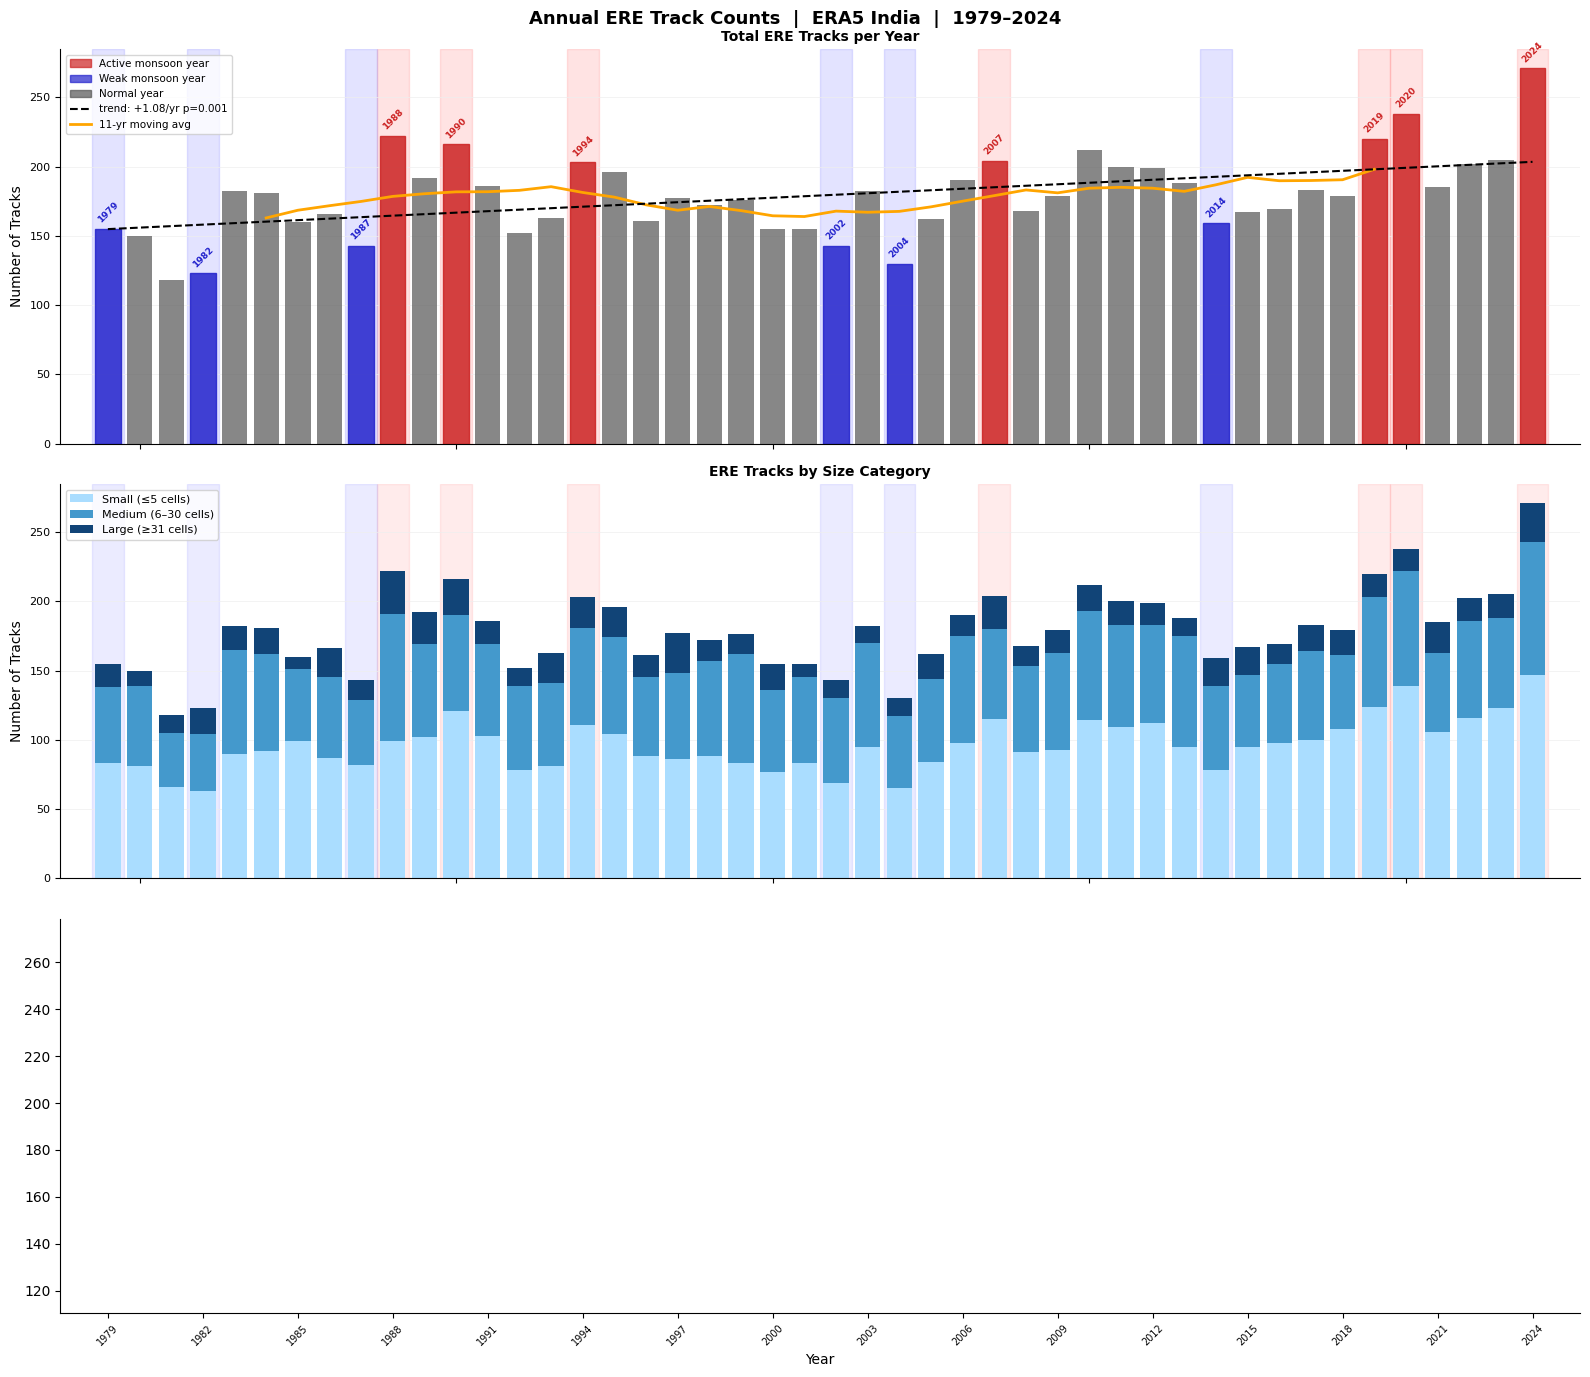

saved → cp3_annual_tracks.png


In [64]:
# ── visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.patch.set_facecolor('white')
fig.suptitle('Annual ERE Track Counts  |  ERA5 India  |  1979–2024',
             fontsize=13, color='black', fontweight='bold')

# ── Panel 1 : total tracks per year with active/weak highlights ──
ax1 = axes[0]
ax1.set_facecolor('white')

# shade active and weak years
for yr in active_years:
    ax1.axvspan(yr-0.5, yr+0.5, color='#ff4444', alpha=0.15, zorder=1)
for yr in weak_years:
    ax1.axvspan(yr-0.5, yr+0.5, color='#4444ff', alpha=0.15, zorder=1)

# bars
bars = ax1.bar(years, annual_tracks,
               color='#555555', alpha=0.7,
               width=0.8, zorder=2)

# colour active/weak bars
for i, (yr, bar) in enumerate(zip(years, bars)):
    if yr in active_years:
        bar.set_color('#cc2222')
        bar.set_alpha(0.85)
    elif yr in weak_years:
        bar.set_color('#2222cc')
        bar.set_alpha(0.85)

# trend line
slope, intercept, r, p, _ = stats.linregress(years, annual_tracks)
trend = slope * years + intercept
ax1.plot(years, trend, color='black', linewidth=1.5,
         linestyle='--', zorder=4,
         label=f'trend: {slope:+.2f}/yr  p={p:.3f}')

# 11yr moving average
ma = np.convolve(annual_tracks, np.ones(11)/11, mode='same')
ma[:5] = np.nan; ma[-5:] = np.nan
ax1.plot(years, ma, color='orange', linewidth=2.0,
         zorder=3, label='11-yr moving avg')

# annotations for active/weak
for yr in active_years:
    idx = yr - 1979
    ax1.text(yr, annual_tracks[idx]+3, str(yr),
             ha='center', va='bottom', fontsize=6.5,
             color='#cc2222', fontweight='bold', rotation=45)
for yr in weak_years:
    idx = yr - 1979
    ax1.text(yr, annual_tracks[idx]+3, str(yr),
             ha='center', va='bottom', fontsize=6.5,
             color='#2222cc', fontweight='bold', rotation=45)

ax1.set_ylabel('Number of Tracks', fontsize=10)
ax1.set_title('Total ERE Tracks per Year', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(axis='y', color='#eeeeee', linewidth=0.5)
ax1.tick_params(labelsize=8)

# legend patches
legend_patches = [
    mpatches.Patch(color='#cc2222', alpha=0.7, label='Active monsoon year'),
    mpatches.Patch(color='#2222cc', alpha=0.7, label='Weak monsoon year'),
    mpatches.Patch(color='#555555', alpha=0.7, label='Normal year'),
]
ax1.legend(handles=legend_patches + [
    plt.Line2D([0],[0], color='black', linestyle='--', label=f'trend: {slope:+.2f}/yr p={p:.3f}'),
    plt.Line2D([0],[0], color='orange', linewidth=2, label='11-yr moving avg'),
], fontsize=7.5, loc='upper left')

# ── Panel 2 : stacked bar by size category ──
ax2 = axes[1]
ax2.set_facecolor('white')

ax2.bar(years, annual_small,  color='#aaddff', width=0.8,
        label='Small (≤5 cells)', zorder=2)
ax2.bar(years, annual_medium, color='#4499cc', width=0.8,
        bottom=annual_small,
        label='Medium (6–30 cells)', zorder=2)
ax2.bar(years, annual_large,  color='#114477', width=0.8,
        bottom=annual_small+annual_medium,
        label='Large (≥31 cells)', zorder=2)

# shade active/weak
for yr in active_years:
    ax2.axvspan(yr-0.5, yr+0.5, color='#ff4444', alpha=0.10, zorder=1)
for yr in weak_years:
    ax2.axvspan(yr-0.5, yr+0.5, color='#4444ff', alpha=0.10, zorder=1)

ax2.set_ylabel('Number of Tracks', fontsize=10)
ax2.set_title('ERE Tracks by Size Category', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(axis='y', color='#eeeeee', linewidth=0.5)
ax2.tick_params(labelsize=8)

# ── Panel 3 : active vs weak year box comparison ──
ax3 = axes[2]
ax3.set_facecolor('white')

active_counts = [annual_tracks[yr-1979] for yr in active_years]
weak_counts   = [annual_tracks[yr-1979] for yr in weak_years]
normal_years  = [yr for yr in years if yr not in active_years and yr not in weak_years]
normal_counts = [annual_tracks[yr-1979] for yr in normal_years]

# box plots
bp = ax3.boxplot(
    [weak_counts, normal_counts, active_counts],
    positions=[1, 2, 3],
    widths=0.5,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5)
)
bp['boxes'][0].set_facecolor('#aabbff')
bp['boxes'][1].set_facecolor('#dddddd')
bp['boxes'][2].set_facecolor('#ffaaaa')

# scatter individual years over boxes
np.random.seed(42)
for pos, counts, col in [
    (1, weak_counts,   '#2222cc'),
    (2, normal_counts, '#555555'),
    (3, active_counts, '#cc2222')
]:
    jitter = np.random.uniform(-0.1, 0.1, len(counts))
    ax3.scatter(pos + jitter, counts,
                color=col, s=40, zorder=5, alpha=0.8)

# annotate each point with year
for yr in active_years:
    idx = active_years.index(yr)
    ax3.annotate(str(yr),
                 (3 + np.random.uniform(-0.1,0.1), active_counts[idx]),
                 textcoords='offset points', xytext=(5,2),
                 fontsize=6.5, color='#cc2222')
for yr in weak_years:
    idx = weak_years.index(yr)
    ax3.annotate(str(yr),
                 (1 + np.random.uniform(-0.1,0.1), weak_counts[idx]),
                 textcoords='offset points', xytext=(5,2),
                 fontsize=6.5, color='#2222cc')

# mean lines
for pos, counts, col in [(1,weak_counts,'#2222cc'),
                          (2,normal_counts,'#555555'),
                          (3,active_counts,'#cc2222')]:
    ax3.hlines(np.mean(counts), pos-0.3, pos+0.3,
               color=col, linewidth=2, linestyle='-',
               zorder=6, label=f'mean={np.mean(counts):.0f}')


for ax in axes:
    ax.set_xlim(1977.5, 2025.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_xticklabels([])
axes[1].set_xticklabels([])
axes[-1].set_xlabel('Year', fontsize=10)
axes[-1].set_xticks(range(1979, 2025, 3))
axes[-1].set_xticklabels(range(1979, 2025, 3), rotation=45, fontsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/cp3_annual_tracks.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("saved → cp3_annual_tracks.png")

**VISUALIZATION**

total active ERE records : 14,864


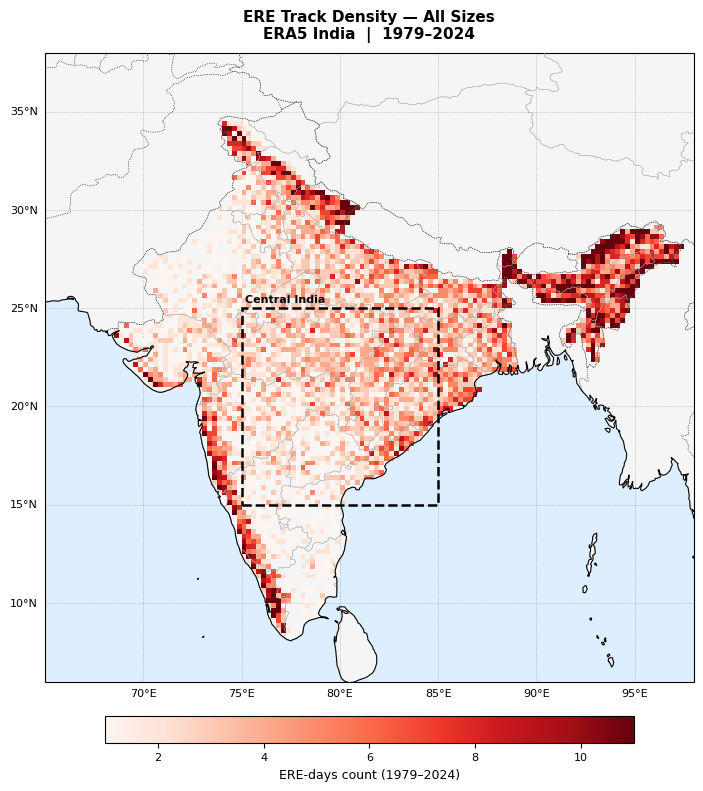

saved → cp3_all_ere_density.png


In [55]:
# ── Track density — All EREs, Nikumbh style ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

active = df[df['event_type'].isin(['birth','continuation'])]
print(f"total active ERE records : {len(active):,}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8),
                        subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_facecolor('white')

ax.set_facecolor('white')
ax.set_extent([65, 98, 6, 38], crs=ccrs.PlateCarree())

# ── map features ──
ax.add_feature(cfeature.OCEAN.with_scale('50m'),  facecolor='#ddeeff')
ax.add_feature(cfeature.LAND.with_scale('50m'),   facecolor='#f5f5f5')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'),
               linewidth=0.8, edgecolor='black', zorder=5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'),
               linewidth=0.5, edgecolor='black',
               linestyle=':', zorder=5)
ax.add_feature(cfeature.STATES.with_scale('50m'),
               linewidth=0.3, edgecolor='#aaaaaa', zorder=4)

# ── compute density per 0.25° cell ──
lat_bins = np.arange(6.0,  38.25, 0.25)
lon_bins = np.arange(65.0, 98.25, 0.25)

dens, _, _ = np.histogram2d(
    active['centre_lat'].values,
    active['centre_lon'].values,
    bins=[lat_bins, lon_bins]
)

lat_centres = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centres = (lon_bins[:-1] + lon_bins[1:]) / 2
LON2D, LAT2D = np.meshgrid(lon_centres, lat_centres)

# ── mask non-India and zero cells ──
dens_masked = np.ma.masked_where(dens == 0, dens.copy()).astype(float)
for li in range(len(lat_centres)):
    for lj in range(len(lon_centres)):
        lat_idx = np.argmin(np.abs(lat - lat_centres[li]))
        lon_idx = np.argmin(np.abs(lon - lon_centres[lj]))
        if not india_mask[lat_idx, lon_idx]:
            dens_masked[li, lj] = np.ma.masked

# ── plot ──
vmax = int(np.percentile(dens[dens > 0], 95))
pcm = ax.pcolormesh(
    LON2D, LAT2D, dens_masked,
    cmap='Reds',
    shading='auto',
    vmin=1,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# ── colorbar ──
cbar = plt.colorbar(pcm, ax=ax,
                    orientation='horizontal',
                    fraction=0.04, pad=0.05,
                    shrink=0.7)
cbar.set_label('ERE-days count (1979–2024)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Central India box — black dashed ──
box = mpatches.Rectangle(
    (75, 15), 10, 10,
    transform=ccrs.PlateCarree(),
    linewidth=1.8,
    edgecolor='black',
    facecolor='none',
    linestyle='--',
    zorder=6
)
ax.add_patch(box)
ax.text(75.2, 25.3, 'Central India',
        transform=ccrs.PlateCarree(),
        fontsize=8, color='black',
        fontweight='bold', zorder=7)

# ── gridlines ──
gl = ax.gridlines(draw_labels=True,
                  linewidth=0.4, color='gray',
                  alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 8, 'color': 'black'}
gl.ylabel_style = {'size': 8, 'color': 'black'}

ax.set_title('ERE Track Density — All Sizes\n'
             'ERA5 India  |  1979–2024',
             fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('/kaggle/working/cp3_all_ere_density.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("saved → cp3_all_ere_density.png")

In [59]:
# ── what does the peak size distribution actually look like ───────────────────
peak_sizes = df[df['event_type'].isin(['birth','continuation'])] \
    .groupby('track_id')['size'].max()

print("Peak size distribution of all tracks:")
print(f"  total tracks     : {len(peak_sizes):,}")
print()
for lo, hi in [(1,5),(6,15),(16,30),(31,50),(51,90),(91,150),(151,999)]:
    n    = ((peak_sizes >= lo) & (peak_sizes <= hi)).sum()
    frac = n / len(peak_sizes) * 100
    print(f"  {lo:>4}–{hi:<4} cells : {n:>6,}  ({frac:.1f}%)")

print()
print(f"  mean peak size   : {peak_sizes.mean():.1f} cells")
print(f"  median peak size : {peak_sizes.median():.1f} cells")
print(f"  90th pct         : {peak_sizes.quantile(0.90):.1f} cells")
print(f"  95th pct         : {peak_sizes.quantile(0.95):.1f} cells")
print(f"  99th pct         : {peak_sizes.quantile(0.99):.1f} cells")
print(f"  max              : {peak_sizes.max()} cells")

Peak size distribution of all tracks:
  total tracks     : 8,239

     1–5    cells :  4,421  (53.7%)
     6–15   cells :  2,051  (24.9%)
    16–30   cells :    950  (11.5%)
    31–50   cells :    424  (5.1%)
    51–90   cells :    283  (3.4%)
    91–150  cells :     91  (1.1%)
   151–999  cells :     19  (0.2%)

  mean peak size   : 12.1 cells
  median peak size : 5.0 cells
  90th pct         : 30.0 cells
  95th pct         : 49.0 cells
  99th pct         : 102.0 cells
  max              : 243 cells
